# Laboratorio 3: Sistema de Búsqueda
## Estudio experimental del escalamiento de listas, árboles binarios de búsqueda y árboles B+

- **Curso:** Estructuras de datos y laboratorio.
- **Autor:** Daniel Sánchez Escobar 
- **Fecha:** 8/10/2026  

### Resumen
Este informe estudia experimentalmente cómo cambia el tiempo de ejecución de un sistema de
administración de estudiantes según la estructura de datos que lo soporta: una lista de Python,
un árbol binario de búsqueda (ABB) y un árbol B+. Se miden las operaciones de búsqueda por ID,
inserción, listado ordenado y búsqueda por rango, variando el tamaño de los datos (N), el orden
de inserción (aleatorio u ordenado) y otros parámetros. Los resultados se comparan con la
complejidad teórica de cada estructura.

> **Uso de IA:** este trabajo se desarrolló con asistencia de herramientas de IA, autorizada por el
> enunciado del laboratorio. El detalle está en la sección final "Uso de IA y código de honor".

## 1. Problema y objetivo

### El problema
Una institución educativa necesita administrar los registros de sus estudiantes. Cada registro
contiene un **ID** único de matrícula, un **nombre**, una **edad** y un **promedio** académico.
El sistema debe permitir:

1. **Buscar** un estudiante a partir de su ID.
2. **Insertar** un nuevo estudiante.
3. **Listar** todos los estudiantes en orden ascendente de ID.

Además de las tres operaciones del enunciado, se implementó la **búsqueda por rango de ID**
(todos los estudiantes con ID entre `lb` y `ub`).

Los registros usados en los experimentos son **sintéticos**: los IDs, edades y promedios se
generan con semillas fijas (reproducibles) y los nombres se toman de un conjunto generado con
la librería Faker.

### Objetivo
Estudiar experimentalmente cómo las distintas estrategias de almacenamiento y búsqueda
(lista, ABB y árbol B+) afectan el tiempo de ejecución a medida que crece el tamaño de los
datos, y contrastar los resultados con la complejidad teórica. Las conclusiones se sustentan
en mediciones repetidas y análisis estadístico.

### Preguntas que guían el estudio
- ¿Los tiempos medidos se comportan como predice la complejidad teórica?
- ¿Qué ocurre con el ABB cuando los datos se insertan ordenadamente, y qué relación hay entre la altura del árbol y el tiempo de búsqueda?
- ¿Qué diferencias aparecen entre datos aleatorios y ordenados?
- ¿A partir de qué tamaño de entrada se vuelven claramente visibles las diferencias entre estructuras?
- ¿Existen costos constantes que hagan que algoritmos de distinta complejidad tengan tiempos similares con entradas pequeñas?

### Variables del estudio
| Variable | Valores |
|---|---|
| Estructura | Lista, ABB, árbol B+ |
| Tamaño de los datos (N) | 100, 1000, 10000, 100000 |
| Número de búsquedas por medición (M) | 1000 en búsquedas puntuales y 100 en búsquedas por rangos |
| Orden de inserción | IDs aleatorios, IDs ordenados |
| Tamaño de los rangos (k) | se usan rangos de k = 50 datos |
| Orden del árbol B+ | 4 |

## 2. Estructuras de datos y algoritmos

Las tres estructuras implementan la misma interfaz (clase abstracta `Estructura`) con las
operaciones `insertar`, `buscar`, `listar` y `buscar_rango_id`, de modo que las mediciones
comparan implementaciones intercambiables. Las clases están en archivos `.py` del repositorio
y se importan en este notebook.

**Notación:** 
- N = número de estudiantes almacenados 
- h = altura del árbol
- k = número de estudiantes que devuelve una consulta por rango
- n = orden/factor de ramificación del árbol B+.
- M = tamaño del lote de claves de búsqueda (para experimentos sobre búsquedas)

### 2.1 Lista de Python (`GestorListaEstudiantes`)
Los estudiantes se guardan en una lista nativa, en el orden en que llegan.
- **Insertar:** `append` al final, sin comparar con los elementos existentes.
- **Buscar:** recorrido lineal hasta encontrar el ID (o terminar la lista si no existe).
- **Listar:** como la lista no está ordenada, se ordena una copia con `sorted` y luego
  se recorre.
- **Rango:** se recorre toda la lista filtrando los IDs dentro de [lb, ub] y solo se ordenan las
  coincidencias.

### 2.2 Árbol binario de búsqueda (`ABB`)
Cada nodo guarda un estudiante y referencias a sus hijos izquierdo y derecho. Los IDs menores o
iguales van a la izquierda y los mayores a la derecha. El árbol **no se balancea**, su forma
depende del orden de inserción.

Los algoritmos de **inserción** y **búsqueda** son las versiones iterativas presentadas en
*Introduction to Algorithms* (Cormen, Leiserson, Rivest y Stein), traducidas a Python. El
**recorrido in-orden** para listar parte del algoritmo del mismo libro, que es recursivo, pero aquí se
implementó de forma **iterativa con pila explícita**.

- **Insertar y buscar:** descenso iterativo desde la raíz.
- **Listar:** recorrido in-orden iterativo con pila explícita (evita el límite de recursión de
  Python en árboles muy profundos), que visita los IDs en orden ascendente.
- **Rango:** descenso a la primera clave ≥ lb y recorrido in-orden, descartando subárboles
  fuera del rango y deteniéndose al superar ub.
- **Altura:** recorrido por niveles, usado en el experimento que relaciona altura y tiempo.

### 2.3 Árbol B+ (`ArbolBPlus`)
Árbol balanceado de orden n: cada nodo tiene como máximo n punteros y n−1 claves. Los datos
están solo en las **hojas**, que además se enlazan entre sí en una lista ligada. Los nodos
internos solo guardan claves de búsqueda. Todas las hojas están a la misma profundidad.

Los algoritmos de **búsqueda**, **inserción** (con división de hojas y nodos internos) y
**búsqueda por rango** son los presentados en *Database System Concepts* (Silberschatz, Korth y Sudarshan), traducidos a Python.

- **Insertar:** se desciende a la hoja correspondiente. Si está llena, se divide en dos y la
  clave separadora sube al padre (que puede dividirse a su vez, hasta llegar a crear una nueva raíz).
- **Buscar:** descenso desde la raíz hasta la hoja y búsqueda de la clave dentro de ella. En cada
  nodo la búsqueda es lineal.
- **Listar:** se baja a la hoja más a la izquierda y se recorren las hojas enlazadas, sin volver
  a subir por el árbol.
- **Rango:** descenso hasta la hoja de `lb` y recorrido de las hojas enlazadas hasta superar `ub`.

### 2.4 Complejidad teórica (la predicción que se contrastará con los datos)
| Estructura | Insertar | Buscar | Listar | Rango |
|---|---|---|---|---|
| Lista | O(1) | O(N) para búsqueda lineal | O(N log N) debido al ordenamiento previo | O(N + k log k) |
| ABB, IDs aleatorios | O(log N) esperado (equilibrado) | O(log N) esperado (equilibrado) | O(N) (recorrer el total de nodos)| O(log N + k) esperado |
| ABB, IDs ordenados | O(N) por inserción (O(N²) construir todo) | O(N) | O(N) | O(N + k) |
| Árbol B+ (orden fijo) | O(log N) | O(log N) | O(N) | O(log N + k) |

A continuación, en cada experimento se comprueba si los tiempos
medidos la respaldan o no.

## 3. Entorno de ejecución

Todos los tiempos de este informe se midieron en el equipo y con el software descritos a
continuación. Los resultados son válidos para este entorno: en otro equipo cambiarán los
valores absolutos, aunque no necesariamente las tendencias. Las versiones exactas de las
librerías están en `requirements.txt`.

In [1]:
import sys
import platform
import subprocess
from importlib import metadata

import psutil


def nombre_cpu() -> str:
    """
    Devuelve el nombre comercial del procesador. platform.processor() suele venir
    vacío o genérico, así que se consulta según el sistema operativo: registro de
    Windows, sysctl en macOS o /proc/cpuinfo en Linux.

    Origen: generada con asistencia de IA (Claude, Anthropic, octubre 2026),
    autorizado por el enunciado del Laboratorio 3.
    Verificación: se validó que efectivamente coincide con las características del sistema.
    """
    try:
        if platform.system() == "Windows":
            import winreg
            clave = winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE,
                                   r"HARDWARE\DESCRIPTION\System\CentralProcessor\0")
            return winreg.QueryValueEx(clave, "ProcessorNameString")[0].strip()
        if platform.system() == "Darwin":
            return subprocess.check_output(
                ["sysctl", "-n", "machdep.cpu.brand_string"], text=True).strip()
        with open("/proc/cpuinfo") as archivo:
            for linea in archivo:
                if linea.startswith("model name"):
                    return linea.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or "No disponible"


# Hardware
memoria = psutil.virtual_memory()
print(f"CPU: {nombre_cpu()}")
print(f"Núcleos: {psutil.cpu_count(logical=False)} físicos, {psutil.cpu_count(logical=True)} lógicos")
print(f"RAM: {memoria.total / 1024**3:.1f} GB (disponible al iniciar: {memoria.available / 1024**3:.1f} GB)")

# Software
print(f"Sistema operativo: {platform.system()} {platform.release()} ({platform.machine()})")
print(f"Python: {platform.python_version()}")
for libreria in ["faker", "psutil", "numpy", "pandas", "matplotlib"]:   # ajusta a las que uses
    try:
        print(f"  {libreria}: {metadata.version(libreria)}")
    except metadata.PackageNotFoundError:
        print(f"  {libreria}: no instalada")

# Condiciones de la medición 
print("Condiciones: portátil, [conectado a corriente: sí], modo de energía [Mayor rendimiento], "
      "programas abiertos: [VS Code]")

# Versiones exactas de todo lo instalado, para reconstruir el entorno
with open("requirements.txt", "w", encoding="utf-8") as archivo:
    archivo.write(subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True))

CPU: AMD Ryzen 5 5500U with Radeon Graphics
Núcleos: 6 físicos, 12 lógicos
RAM: 7.3 GB (disponible al iniciar: 1.7 GB)
Sistema operativo: Windows 11 (AMD64)
Python: 3.14.7
  faker: 40.1.2
  psutil: 7.2.2
  numpy: 2.5.2
  pandas: 3.0.6
  matplotlib: 3.11.2
Condiciones: portátil, [conectado a corriente: sí], modo de energía [Mayor rendimiento], programas abiertos: [VS Code]


## 4. Parámetros globales

Los valores de esta sección fueron **sugeridos con asistencia de IA** (Claude, Anthropic).

| Parámetro | Valor | Por qué |
|---|---|---|
| Tamaños de datos (N) | 100, 1000, 10000, 100000 | Cada tamaño es 10 veces el anterior. Esto cubre cuatro órdenes de magnitud con pocos puntos. Incluye 10.000, el caso del enunciado. |
| Búsquedas por medición (M) | 1000 o 100 (para rangos)  | Una sola búsqueda es demasiado rápida para medirla con fiabilidad, mil hacen que el tiempo total sea medible incluso con N pequeño. |
| Búsquedas exitosas | 80 % | La mayoría busca IDs que existen, y el 20 % restante busca IDs inexistentes, para incluir también el costo de una búsqueda fallida. |
| Repeticiones | 30 | Suficientes para calcular promedio y demás estadísticas. |
| Calentamiento | 3 ejecuciones descartadas | Las primeras ejecuciones suelen ser más lentas y no son representativas. |
| Orden del árbol B+ | 4 | Es el orden que se usó al implementarlo. |
| Tamaño del rango (k) | 50 | Cada búsqueda por rango devuelve exactamente 50 estudiantes, sin importar el tipo de datos. |



## 5. Metodología

> Sección redactada con asistencia de IA (Claude, Anthropic) y revisada por mí.

Esta sección explica cómo se mide el **tiempo de ejecución** de cada operación al probar tres estructuras de datos (Lista, Árbol Binario de Búsqueda o ABB, y Árbol B+), variando la cantidad de datos ($N$) y su orden (aleatorio u ordenado).

### 5.1 Entorno de pruebas (Hardware y software)

Las mediciones se realizan en un único equipo de cómputo. Los tiempos en milisegundos o segundos pueden cambiar si el código se ejecuta en otra computadora más rápida o lenta, pero la tendencia de crecimiento y las comparaciones entre algoritmos se mantendrán iguales.


### 5.2 Tamaños de entrada

Probamos con cinco tamaños de datos: **$N = 100$, $1000$, $10000$, $100000$** estudiantes.

* **Por qué se eligen estos valores:** Cada número es 10 veces mayor que el anterior. Al graficar en una escala logarítmica (donde los ejes avanzan multiplicándose por 10), estos puntos quedan separados a la misma distancia, lo que facilita ver cómo aumenta el tiempo al crecer $N$.
* **Medición por lotes ($M = 1000$ o $M = 100$):** Medir el tiempo de buscar un solo estudiante es impredecible porque toma fracciones de microsegundo. Para solucionarlo, en cada prueba se ejecutan **$M = 1000$ búsquedas puntuales seguidas o $M = 100$ búsquedas por rango seguidas** y se mide el tiempo total del lote.

### 5.3 Generación de los datos

Generamos los datos de los estudiantes en dos escenarios para evaluar el comportamiento bajo distintas condiciones:

| Tipo de datos | Cómo se generan los IDs | Por qué se utiliza |
| --- | --- | --- |
| **Aleatorios** | $N$ identificadores únicos elegidos al azar entre $1$ y $10 \cdot N$. | Representa el uso normal. En el ABB, los datos desordenados producen un árbol aproximadamente balanceado (con alturas similares en sus ramas). |
| **Ordenados** | Identificadores en secuencia estricta: $1, 2, 3, \dots, N$. | Representa el peor escenario para el ABB. Insertar datos ordenados hace que el árbol no se ramifique y se transforme en una lista larga. |

El rango hasta $10 \cdot N$ deja "huecos" entre los identificadores, lo que permite probar qué pasa cuando se busca un registro que no existe. Cada repetición utiliza una **semilla numérica** (un número inicial para el generador de azar), lo que garantiza que los datos generados sean exactamente los mismos si se vuelve a correr el código.


### 5.4 Generación de las búsquedas

Para comparar las estructuras de forma justa, en cada repetición la Lista, el ABB y el Árbol B+ reciben **exactamente la misma información y las mismas consultas**:

* **Búsqueda por ID puntual:** Se busca un lote de $M = 1000$ IDs. El 80% de las consultas son de estudiantes que sí existen en la estructura y el 20% son de IDs inexistentes, evaluando ambos casos.
* **Búsqueda por rango:** Se buscan $M = 100$ rangos. Para que la comparación sea justa, cada rango se define para recuperar **exactamente $k = 50$ estudiantes**. De este modo, todas las estructuras realizan el mismo trabajo de lectura.

### 5.5 Control y medición del tiempo

Para obtener tiempos precisos y libres de interferencias externas, aplicamos los siguientes mecanismos:

* **Reloj de alta precisión (`time.perf_counter_ns()`):** Lee el tiempo directamente del procesador en nanosegundos ($1\text{ segundo} = 1.000.000.000\text{ nanosegundos}$).
* **Aislamiento de la prueba:** El reloj solo mide la ejecución del algoritmo de búsqueda o inserción. La creación previa de los datos en memoria queda fuera del cronómetro.
* **Desactivación del recolector de basura (`gc.disable()`):** Python limpia la memoria no utilizada de forma automática. Desactivamos este proceso durante la medición para evitar que una limpieza espontánea infle el tiempo de una prueba.
* **Fase de calentamiento:** Se ejecutan 3 repeticiones previas que se descartan. Esto permite que el procesador cargue el código en su memoria rápida (caché) antes de tomar las mediciones definitivas.

### 5.6 Repeticiones y reproducibilidad

Cada configuración (por ejemplo, ejecutar un lote de $M = 1000$ búsquedas en un ABB poblado con $N = 10000$ estudiantes con datos aleatorios) se repite 30 veces.

* **Por qué 30 veces:** El tiempo de ejecución varía levemente en cada intento debido a tareas en segundo plano del sistema operativo. Al tomar 30 mediciones, el promedio resulta estadísticamente confiable (por el Teorema del Límite Central, que establece que el promedio de 30 o más muestras se comporta como una distribución normal suave).
* **Guardado automático:** Cada repetición guarda su resultado directamente en un archivo CSV.

### 5.7 Fórmulas estadísticas utilizadas

Para sintetizar las 30 repeticiones de cada prueba se aplican las siguientes fórmulas:

#### 1. Media ($\bar{x}$)

Es el promedio aritmético de los tiempos de ejecución.

$$\bar{x} = \frac{\sum_{i=1}^{n} t_i}{n}$$

* **Aplicación:** Es el valor representativo que se grafica en el eje vertical de tiempo.

#### 2. Desviación Estándar Muestral ($s$)

Mide qué tan dispersos están los tiempos individuales respecto al promedio.

$$s = \sqrt{\frac{\sum_{i=1}^{n} (t_i - \bar{x})^2}{n - 1}}$$

* **Aplicación:** Indica la estabilidad del sistema. Una desviación alta significa que los tiempos variaron mucho entre una repetición y otra debido a interferencias externas. También se usa principalmente en el cálculo de intervalos de confianza.

#### 3. Mediana y Rango Intercuartílico ($IQR$)

* **Mediana:** Es el dato que queda en el centro al ordenar las 30 mediciones de menor a mayor.
* **IQR ($Q_3 - Q_1$):** Es la diferencia entre el cuartil 3 (el valor que supera al 75% de los datos) y el cuartil 1 (el valor que supera al 25%). Representa el ancho donde se concentra el 50% central de las mediciones.

#### 4. Intervalo de Confianza al 95% (IC 95%)

Calcula el rango dentro del cual se estima la media verdadera del algoritmo con un 95% de confianza.

$$\text{IC 95\%} = \bar{x} \pm \left( t_{0.025, \, n-1} \cdot \frac{s}{\sqrt{n}} \right)$$

Donde:

* $\bar{x}$ es la media muestral.
* $s$ es la desviación estándar.
* $n$ es el número de repeticiones ($n = 30$).
* $t_{0.025, \, n-1}$ es el factor de la distribución $t$ de Student para $29$ grados de libertad ($\approx 2.045$).

**Cómo se aplica en las gráficas:** Se dibuja como barras de error verticales sobre cada punto. Si las barras de dos estructuras no se cruzan (no se solapan), se confirma visualmente que una estructura es más rápida que la otra con validez estadística.

### 5.8 Identificación de valores atípicos (Criterio de Tukey)

Un tiempo atípico (o *outlier*) es una medición anormalmente alta producida por una pausa del sistema operativo o un proceso en segundo plano, y no por una lentitud real del algoritmo.

Para detectar estos picos, definimos dos límites numéricos:

$$\text{Límite Inferior} = Q_1 - 1.5 \cdot IQR$$

$$\text{Límite Superior} = Q_3 + 1.5 \cdot IQR$$

Cualquier tiempo medido que caiga por debajo del límite inferior o por encima del límite superior se considera **atípico**.

* **Aplicación en el proyecto:** Las funciones procesan los datos de dos formas simultáneas, con todos los datos y descartando los atípicos (guardados con el sufijo `_sin`).

### 5.9 Comparación con la complejidad teórica (Pendiente Log-Log)

La teoría indica que el tiempo $T(N)$ de un algoritmo según el tamaño $N$ sigue una ley de potencia:

$$T(N) \approx a \cdot N^b$$

Donde $b$ representa el exponente de complejidad ($b = 1$ para lineal, $b = 2$ para cuadrático, etc.). Al aplicar logaritmo en base 10 a ambos lados de la ecuación, obtenemos una línea recta:

$$\log_{10}(T(N)) = \log_{10}(a) + b \cdot \log_{10}(N)$$

Esta ecuación tiene la forma lineal $y = m \cdot x + c$, donde la pendiente $m$ es igual al exponente $b$.

Calculamos la pendiente mediante una recta de mínimos cuadrados ordinarios sobre los logaritmos de $N$ y del tiempo promedio. La interpretación del resultado es la siguiente:

| Pendiente ($b$) | Tipo de crecimiento | Comportamiento esperado en las estructuras |
| --- | --- | --- |
| **$\approx 0$** | **Constante $O(1)$ / Logarítmico $O(\log N)$** | El tiempo casi no sube al aumentar $N$. |
| **$\approx 1$** | **Lineal $O(N)$** | Si $N$ se multiplica por 10, el tiempo sube 10 veces. |
| **$\approx 2$** | **Cuadrático $O(N^2)$** | Si $N$ se multiplica por 10, el tiempo sube 100 veces ($10^2$). Esperado al construir un ABB insertando datos ya ordenados. |

La anterior tabla sirve para hacer suposiciones empíricas aproximadas, no son demostraciones formales de complejidad computacional. Por ejemplo, si la pendiente es un valor entre 1 y 2, se puede apuntar a un comportamiento superlineal $N\log N$ compatible, pero no es una confirmación definitiva.

## 6. Funciones de utilidad

In [3]:
# Funciones de apoyo para resumir los tiempos, guardarlos y graficarlos.
# Escritas con asistencia de IA (Claude, Anthropic, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3.

import os
import numpy as np                 # cálculos con listas de números
import pandas as pd                # tablas (el CSV se lee y se guarda con pandas)
import matplotlib.pyplot as plt    # gráficas
from scipy import stats            # solo se usa para un número: el factor t del intervalo de confianza

def calcular_estadisticas(tiempos):
    """
    Calcula las estadísticas de UNA lista de tiempos (por ejemplo, las 30
    repeticiones de "ABB con N=10.000").
    Devuelve un diccionario con: n, media, desviación, mediana, iqr, ic_inf, ic_sup.
    (IQR = ancho del 50 % central de los datos. IC = intervalo de confianza del 95 %:
    el rango donde probablemente está la media verdadera.)
    """
    t = np.array(tiempos, dtype=float)
    n = len(t)

    media = t.mean()
    desviacion = t.std(ddof=1)             # ddof=1: desviación "muestral" (divide entre n-1)
    mediana = np.median(t)
    q1, q3 = np.percentile(t, [25, 75])    # cuartiles: valores que dejan 25 % y 75 % de los datos abajo

    # Margen del intervalo de confianza: factor t * desviación / raíz de n
    factor_t = stats.t.interval(0.95, df=n - 1)[1]
    margen = factor_t * desviacion / np.sqrt(n)

    return {
    "n": n, 
    "media": media, 
    "desviacion": desviacion, 
    "mediana": mediana,
    "iqr": q3 - q1, 
    "ic_inf": media - margen, 
    "ic_sup": media + margen
    }


def resumir(tiempos):
    """
    Resume los tiempos de UNA configuración, de dos maneras:
      - con todos los datos (nombres normales: media, desviacion, ...)
      - sin los atípicos (mismos nombres con sufijo "_sin": media_sin, ...)
    Un dato es atípico si queda fuera de [Q1 - 1,5*IQR, Q3 + 1,5*IQR] (criterio de Tukey).
    También devuelve cuántos atípicos hubo ("atipicos").
    """
    t = np.array(tiempos, dtype=float)

    # Límites para detectar atípicos
    q1, q3 = np.percentile(t, [25, 75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # True en los datos normales, False en los atípicos (máscara booleana, un arreglo paralelo de booleanos
    # por cada valor de tiempo)
    es_normal = (t >= limite_inferior) & (t <= limite_superior)

    resumen = calcular_estadisticas(t)                      # con todos los datos (incluyendo atípicos)
    resumen["atipicos"] = int((~es_normal).sum())           # cuántos atípicos hay

    for nombre, valor in calcular_estadisticas(t[es_normal]).items():   # sin los atípicos
        resumen[nombre + "_sin"] = valor
    return resumen

def resumir_tabla(datos, columna_curva, columna_x):
    """
    Aplica resumir() a cada configuración de la tabla de mediciones crudas.
    "datos" debe tener una columna "tiempo_ns" (un tiempo por fila).
      - columna_curva: columna que define cada línea de la gráfica (ej. "estructura")
      - columna_x: columna del eje horizontal (ej. "N")
    Devuelve una tabla con una fila por cada pareja (curva, x).
    """
    filas = []
    for (curva, x), grupo in datos.groupby([columna_curva, columna_x]):
        fila = {columna_curva: curva, columna_x: x}
        fila.update(resumir(grupo["tiempo_ns"]))
        filas.append(fila)
    return pd.DataFrame(filas)

def guardar_csv(datos, nombre):
    """
    Guarda la tabla de mediciones en resultados/<nombre>.csv (crea la carpeta si no existe).
    Para volver a leerla más tarde: pd.read_csv("resultados/<nombre>.csv")
    """
    os.makedirs("resultados", exist_ok=True)
    ruta = f"resultados/{nombre}.csv"
    datos.to_csv(ruta, index=False)
    return ruta

def graficar(resumen, columna_curva, columna_x, titulo, etiqueta_x,
             unidad="ms", sin_atipicos=False, escala_log=True):
    """
    Dibuja una línea por cada valor de `columna_curva`: la media del tiempo en cada x,
    con barras verticales que muestran el intervalo de confianza del 95 %.
    `resumen` es lo que devuelve resumir_tabla().
      - unidad: "ns", "us", "ms" o "s" (unidad del eje vertical)
      - sin_atipicos: False = usa todos los datos; True = usa los datos sin atípicos
      - escala_log: True = ambos ejes en escala logarítmica (para leer la pendiente)
    """
    divisor = {"ns": 1, "us": 1e3, "ms": 1e6, "s": 1e9}[unidad]   # los tiempos están en ns
    sufijo = "_sin" if sin_atipicos else ""

    plt.figure(figsize=(8, 5))
    for curva, tabla in resumen.groupby(columna_curva):
        tabla = tabla.sort_values(columna_x)
        media = tabla["media" + sufijo] / divisor
        abajo = media - tabla["ic_inf" + sufijo] / divisor      # largo de la barra hacia abajo
        arriba = tabla["ic_sup" + sufijo] / divisor - media     # largo de la barra hacia arriba
        plt.errorbar(tabla[columna_x], media, yerr=[abajo, arriba],
                     marker="o", capsize=3, label=curva)

    if escala_log:
        plt.xscale("log")
        plt.yscale("log")
    plt.title(titulo + (" (sin atípicos)" if sin_atipicos else ""))
    plt.xlabel(etiqueta_x)
    plt.ylabel(f"Tiempo medio ({unidad})  |  barras: IC 95 %")
    plt.legend(title=columna_curva)
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

def pendiente_loglog(x, tiempo):
    """
    Calcula la pendiente de la recta que mejor se ajusta a log10(tiempo) contra log10(x).
    Esa pendiente es el exponente de crecimiento:
    cerca de 0 = casi constante o logarítmico, cerca de 1 = lineal, cerca de 2 = cuadrático.
    """
    # 1. Convierte las entradas N y los tiempos a escala logarítmica
    x_log = np.log10(x) # (Los distintos tamaños de entrada)
    y_log = np.log10(tiempo) # (Los tiempos de cada tamaño de entrada)

    # 2. Ajusta una recta de grado 1 (y = m*x + b) usando mínimos cuadrados ordinarios
    #    Devuelve una lista con dos elementos: [pendiente, interseccion]
    resultado = np.polyfit(x_log, y_log, 1)

    # 3. Toma únicamente la pendiente m (descartando b mediante _)
    pendiente, _ = resultado

    return pendiente

# 2. Experimentos:

## Experimento 0: pruebas de correctitud

> Nota: Sección redactada con asistencia de IA (Gemini) y revisada por Daniel Sánchez Escobar.

**Pregunta:** ¿Las tres estructuras de datos (Lista, ABB y Árbol B+) funcionan correctamente y devuelven los mismos resultados en las operaciones de buscar, insertar, listar y buscar por rango?

**Hipótesis:** Sí. Todas las estructuras deben comportarse de forma idéntica respecto a los datos devueltos. Cualquier diferencia indica un error de programación que debe corregirse antes de medir tiempos en los siguientes experimentos.

### Diseño:

Para cada prueba se construyen la Lista, el ABB y el Árbol B+ insertando exactamente los mismos datos de estudiantes. Luego se verifica que:

1. Los métodos "listar" de cada implementación coincidan exactamente en cuánto a los ID's de los estudiantes, tanto en existencia como en orden.
2. Los métodos "buscar" de cada implementación encuentren a un mismo estudiante puntual por su ID.
3. Que el método "buscar" indique correctamente que un estudiante no fue encontrado para ID's inexistentes.
4. Los métodos "buscar_rango_id" devuelvan exactamente los registros dentro del rango solicitado, respondiendo bien en casos límite (rangos de un solo elemento, rangos vacíos o rangos invertidos).
5. Para los árboles, la función "altura" devuelva 0 únicamente cuando la estructura no tiene elementos ($N = 0$), y que en el ABB coincida exactamente con $N$ cuando los datos entran ordenados o de forma descendente.

#### Variables del experimento
| Variable | Valores probados |
|---|---|
| Cantidad de datos (N) | 0, 1, 2, 3, 10, 100, 1000 |
| Orden de inserción | aleatorio, ascendente, descendente |
| Orden del Árbol B+ | 4, 5, 8 |
| Semillas aleatorias | 1000 a 1004 |

In [ ]:
import re
import pandas as pd
from ABB import ABB
from ArbolBPlus import ArbolBPlus
from GestorListaEstudiantes import GestorListaEstudiantes
from funciones_auxiliares import generar_estudiantes

# Escritas con asistencia de IA (Claude, Anthropic, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3.

def extraer_ids(texto: str) -> list:
    """
    Busca en el texto devuelto por las estructuras y extrae únicamente los números de ID.
    Sirve para comparar rápidamente si las funciones listar() o buscar_rango_id() 
    están devolviendo los IDs correctos y en el orden esperado.
    """
    return [int(x) for x in re.findall(r"id : (\d+)", texto)]

def texto_busqueda_esperado(estudiante: dict) -> str:
    """Construye exactamente el mismo texto que debería devolver una búsqueda exitosa."""
    return "Encontrado :\n" + "".join(f"{k} : {v} | " for k, v in estudiante.items())

def validar_estructuras(n: int, tipo: str, orden_bplus: int, semilla: int) -> list:
    """
    Construye la Lista, el ABB y el B+ con 'n' estudiantes y prueba cada operación.
    Devuelve una lista con los fallos encontrados. Si todo está bien, devuelve una lista vacía.
    """
    # 1. Preparar los datos de prueba dependiendo del orden elegido
    estudiantes_crudos = generar_estudiantes(n, ordenados=(tipo != "aleatorio"), semilla=semilla)
    if tipo == "descendente":
        estudiantes_crudos = estudiantes_crudos[::-1] # Esta acción invierte la lista.
    
    ids_esperados = sorted([e["id"] for e in estudiantes_crudos])
    
    # 2. Inicializar las tres estructuras
    estructuras = {
        "Lista": GestorListaEstudiantes([]),
        "ABB": ABB(),
        f"B+ (orden {orden_bplus})": ArbolBPlus(orden_bplus),
    }

    fallos = []

    # 3. Evaluar cada estructura paso a paso
    for nombre, estructura in estructuras.items():
        
        # Prueba A: Insertar los estudiantes
        for e in estudiantes_crudos:
            estructura.insertar(e)

        # Prueba B: Listar (debe devolver todos los IDs en orden ascendente)
        if extraer_ids(estructura.listar()) != ids_esperados:
            fallos.append((nombre, "listar no ordenó bien o faltan datos"))

        # Prueba C: Buscar estudiantes que SÍ existen
        for e in estudiantes_crudos:
            if estructura.buscar(e["id"]) != texto_busqueda_esperado(e):
                fallos.append((nombre, "buscar falló con estudiante existente"))

        # Prueba D: Buscar estudiantes que NO existen
        ids_inexistentes = [0, 999999, 999998] # IDs que sabemos que no se generaron
        for id_falso in ids_inexistentes:
            esperado = f"Estudiante con id: {id_falso} no fue encontrado."
            if estructura.buscar(id_falso) != esperado:
                fallos.append((nombre, "buscar falló con estudiante inexistente"))

        # Prueba E: Validar la altura (si la estructura tiene ese método)
        if hasattr(estructura, "altura"):
            h = estructura.altura()
            if n == 0 and h != 0:
                fallos.append((nombre, "altura no es 0 en estructura vacía"))
            # En un ABB insertado en orden, la altura debe ser igual a N
            if nombre == "ABB" and tipo != "aleatorio" and h != n:
                fallos.append((nombre, "altura incorrecta en ABB degenerado"))

        # Prueba F: Insertar un dato nuevo después de haber llenado la estructura
        estudiante_nuevo = {"id": 888888, "nombre": "Prueba", "edad": 20, "promedio": 4.0}
        estructura.insertar(estudiante_nuevo)
        
        if estructura.buscar(estudiante_nuevo["id"]) != texto_busqueda_esperado(estudiante_nuevo):
            fallos.append((nombre, "no se pudo buscar el estudiante recién insertado"))

        # Prueba G: búsquedas por rango
        if ids_esperados:
            casos_rango = [
                (ids_esperados[0], ids_esperados[-1]),             # 1. Rango completo
                (ids_esperados[0], ids_esperados[0]),              # 2. Un solo ID
                (0, ids_esperados[-1] + 100),                      # 3. Rango amplio que cubre todo
                (ids_esperados[-1] + 10, ids_esperados[-1] + 50), # 4. Rango fuera de los datos (vacío)
                (50, 10)                                           # 5. Límite inferior mayor que el superior (lb > ub)
            ]
        else:
            casos_rango = [(1, 10)]  # Caso especial cuando N = 0 (estructura vacía)

        for lb, ub in casos_rango:
            # Generamos la lista matemática con los IDs que DEBERÍAN estar dentro del rango [lb, ub]
            ids_rango_esperados = [i for i in ids_esperados if lb <= i <= ub]
            
            # Consultamos la estructura
            texto_rango = estructura.buscar_rango_id(lb, ub)
            
            # Comparamos únicamente los IDs devueltos contra los esperados
            if extraer_ids(texto_rango) != ids_rango_esperados:
                fallos.append((nombre, f"buscar_rango_id [{lb}, {ub}]"))

    return fallos

In [5]:
N_E0 = [0, 1, 2, 3, 10, 100, 1000] # Tamaños de entrada
fallos_totales = []
combinaciones = 0

for n in N_E0: # Para cada tamaño de entrada
    for tipo in ["aleatorio", "ordenado", "descendente"]: # Para cada configuración de los datos
        for orden in [4, 5, 8]: # Para cada orden (para el árbol B+)
            for semilla in range(1000, 1005): # Semillas fijas de aleatorización
                combinaciones += 1
                errores = validar_estructuras(n, tipo, orden, semilla)
                
                # Registrar detalles de cada fallo encontrado
                for estructura, prueba in errores:
                    fallos_totales.append({
                        "N": n, 
                        "tipo": tipo, 
                        "orden_B+": orden, 
                        "estructura": estructura, 
                        "prueba": prueba
                    })

print(f"Total de combinaciones probadas: {combinaciones}")
print(f"Total de fallos encontrados: {len(fallos_totales)}")

if fallos_totales:
    df_fallos = pd.DataFrame(fallos_totales)
    display(df_fallos.groupby(["estructura", "prueba"]).size())
else:
    print("¡Éxito! Todas las estructuras pasaron las pruebas de correctitud.")

Total de combinaciones probadas: 315
Total de fallos encontrados: 0
¡Éxito! Todas las estructuras pasaron las pruebas de correctitud.


### Análisis y conclusión del experimento 0
Se evaluaron exitosamente las 315 combinaciones planificadas, abarcando variaciones en la cantidad de datos ($N \in \{0, 1, 2, 3, 10, 100, 1000\}$), el orden de entrada (aleatorio, ascendente y descendente), el orden del Árbol B+ ($n \in \{4, 5, 8\}$) y distintas semillas de aleatorización. Ninguna de las tres estructuras presentó fallos en las pruebas funcionales de inserción, búsqueda individual, listado completo, cálculo de altura (solo en árboles) ni búsquedas por rango. Dado que no se registraron errores de lógica ni inconsistencias en los datos retornados, se concluye que la Lista, el ABB y el Árbol B+ implementan de forma correcta las operaciones requeridas y responden de manera funcionalmente equivalente. Las tres estructuras se encuentran en un estado estable y listas para ser sometidas a las pruebas de rendimiento temporal y espacio en los experimentos posteriores.

#### Limitaciones
1. Cobertura no exhaustiva de casos: el hecho de que todas las pruebas hayan sido superadas no constituye una demostración formal de la ausencia total de errores (bugs), sino únicamente que no se detectaron fallos dentro de los escenarios evaluados.
2. Tamaño máximo de entrada: la validación funcional se limitó a un máximo de $N = 1000$ elementos. Aunque es suficiente para verificar la lógica de punteros, reestructuraciones y divisiones de nodos, no evalúa comportamientos bajo cargas masivas.

## Experimento 1 : Tiempo de búsquedas aleatorias

> Sección redactada con asistencia de IA (Gemini) y revisada por Daniel Sánchez Escobar.

**Pregunta:** ¿El tiempo necesario para procesar un lote de $M = 1000$ búsquedas puntuales en el ABB y en el Árbol B+ crece a ritmo logarítmico $O(\log N)$ mientras que en la Lista crece a ritmo lineal $O(N)$ cuando los datos están desordenados? ¿A partir de qué tamaño de entrada ($N$) la diferencia de tiempo entre las estructuras se vuelve significativa?

**Hipótesis:** Para volúmenes pequeños de datos ($N = 100$), las tres estructuras presentarán tiempos de respuesta cercanos en escala absoluta. A medida que $N$ se incrementa ($N \ge 1000$), el tiempo acumulado de la Lista crecerá de forma lineal pronunciada con una pendiente en escala log-log cercana a $1.0$, mientras que el ABB y el Árbol B+ mantendrán curvas casi planas con un crecimiento logarítmico de pendiente log-log cercana a $0.0$.

### Diseño:
Para evaluar el comportamiento operacional de cada estructura de datos frente al escalamiento de los datos, el diseño sigue un procedimiento estandarizado:
1. Generación de datos y estructuras: Para cada tamaño de entrada $N \in \{100, 1000, 10000, 100000\}$, se generan $N$ registros de estudiantes con identificadores únicos elegidos al azar en el rango de $1$ a $10 \cdot N$. Estos mismos datos se insertan secuencialmente en la Lista, el ABB y el Árbol B+ ($orden = 4$).
2. Variación de semilla por repetición: Para garantizar la variabilidad geométrica del árbol y la independencia estadística, cada repetición $i \in \{0, 1, \dots, 29\}$ utiliza una semilla única para la generación de los estudiantes ($\text{semilla} = 1000 + i$). Las consultas se generan con un desplazamiento fijo ($\text{semilla} = 1000 + i + 5000$) para evitar coincidencias o patrones no deseados con la secuencia del generador de datos.
3. Generación de consultas: En cada repetición se construye un lote idéntico de $M = 1000$ búsquedas de ID puntual, compuesto en un $80\%$ por identificadores existentes en las estructuras y un $20\%$ por identificadores inexistentes.
4. La medición se realiza deshabilitando el recolector de basura (gc.disable()) para prevenir interrupciones espontáneas del runtime. Antes de registrar la medición oficial, se ejecutan $3$ pasadas previas de calentamiento que son descartadas con el objetivo de cargar las instrucciones y punteros en la memoria caché del procesador. Posteriormente, se mide el tiempo total de ejecución del lote de consultas mediante time.perf_counter_ns().
5. Cada ejecución guarda su resultado de forma explícita en un registro de mediciones crudas (e1_mediciones_crudas.csv), asociando el valor de $N$, el número de repetición, la semilla utilizada, la estructura evaluada y el tiempo en nanosegundos. Esto permite calcular posteriormente la media, la desviación estándar, la mediana, el rango intercuartílico y los intervalos de confianza al $95\%$.

#### Variables del experimento:

| Variable | Configuración / Valor probado |
|---|---|
| Tamaños de entrada ($N$) | $100$, $1000$, $10000$, $100000$ estudiantes |
| Tamaño del lote ($M$) | $1.000$ búsquedas puntuales por medición |
| Proporción de consultas | $80\%$ búsquedas exitosas / $20\%$ búsquedas fallidas |
| Orden de inserción | Aleatorio (IDs desordenados en el rango de $1$ a $10 \cdot N$) |
| Orden del Árbol B+ ($n$) | $4$ |
| Repeticiones ($n_{\text{rep}}$) | $30$ repeticiones independientes por cada combinación |
| Control de reproducibilidad | Semilla variable por repetición ($\text{semilla} = 1000 + i$) |
| Protocolo de medición | `gc.disable()`, $3$ ejecuciones de calentamiento descartadas, `time.perf_counter_ns()` |

Ejecutando pruebas para N = 100...
Ejecutando pruebas para N = 1,000...
Ejecutando pruebas para N = 10,000...
Ejecutando pruebas para N = 100,000...

¡Pruebas finalizadas!
Mediciones crudas guardadas en: resultados/e1_mediciones_crudas.csv
Resumen estadístico guardado en: resultados/e1_busquedas_vs_n.csv


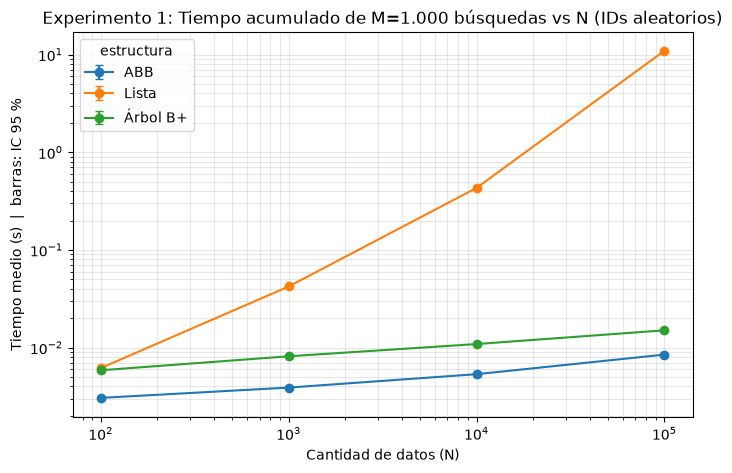

In [ ]:
# Escritas con asistencia de IA (Gemini, Google, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3.

import pandas as pd

# Importar las clases de las estructuras de datos
from ABB import ABB
from ArbolBPlus import ArbolBPlus
from GestorListaEstudiantes import GestorListaEstudiantes

# Importar funciones de generación y medición
from funciones_auxiliares import (
    generar_estudiantes,
    generar_ids_busqueda,
    medir_busquedas
)


# 1. Configuración de parámetros globales
TAMANOS_N = [100, 1_000, 10_000, 100_000]
M_BUSQUEDAS = 1_000
PROPORCION_EXITOSAS = 0.8
REPETICIONES = 30
SEMILLA_BASE = 1000
ORDEN_BPLUS = 4

mediciones_crudas = []


# 2. Bucle experimental (semilla única por repetición)
for n in TAMANOS_N:
    print(f"Ejecutando pruebas para N = {n:,}...")
    
    # Se realizan 30 repeticiones independientes cambiando la semilla en cada iteración
    for i in range(REPETICIONES):
        semilla_estudiantes = SEMILLA_BASE + i
        semilla_busquedas = SEMILLA_BASE + i + 5000  # Desplazamiento para no repetir la secuencia del generador
        
        # Paso A: Generar estudiantes con la semilla i-ésima
        estudiantes = generar_estudiantes(n, ordenados=False, semilla=semilla_estudiantes)
        
        # Paso B: Construir las estructuras con los mismos estudiantes
        lista = GestorListaEstudiantes(estudiantes.copy())
        
        abb = ABB()
        abb.construir_arbol(estudiantes)
        
        bplus = ArbolBPlus(ORDEN_BPLUS)
        bplus.construir_arbol(estudiantes)
        
        # Paso C: Generar el lote de M=1.000 búsquedas
        ids_busqueda = generar_ids_busqueda(
            estudiantes, 
            M_BUSQUEDAS, 
            PROPORCION_EXITOSAS, 
            semilla=semilla_busquedas
        )
        
        estructuras = {
            "Lista": lista,
            "ABB": abb,
            "Árbol B+": bplus
        }
        
        # Paso D: Medir y registrar el tiempo de cada estructura junto con su semilla
        for nombre, est in estructuras.items():

            # Fase de calentamiento (3 pasadas descartadas para cargar caché de la CPU)
            for _ in range(CALENTAMIENTO):
                _ = medir_busquedas(est, ids_busqueda)
                
            tiempo_ns = medir_busquedas(est, ids_busqueda)
            
            mediciones_crudas.append({
                "N": n,
                "repeticion": i,
                "semilla": semilla_estudiantes,  # Guardado explícito para reproducibilidad
                "estructura": nombre,
                "tiempo_ns": tiempo_ns
            })


# 3. Exportación a CSV y resumen estadístico
# Convertir a DataFrame y guardar mediciones crudas (cada fila representa una repetición reproducible)
df_crudas = pd.DataFrame(mediciones_crudas)
ruta_crudas = guardar_csv(df_crudas, "e1_mediciones_crudas")

# Calcular estadísticas (media, desviación e intervalo de confianza 95%) agrupando por estructura y N
df_resumen = resumir_tabla(df_crudas, columna_curva="estructura", columna_x="N")
ruta_resumen = guardar_csv(df_resumen, "e1_busquedas_vs_n")

print(f"\n¡Pruebas finalizadas!")
print(f"Mediciones crudas guardadas en: {ruta_crudas}")
print(f"Resumen estadístico guardado en: {ruta_resumen}")


# 4. Generación de gráfica
graficar(
    resumen=df_resumen,
    columna_curva="estructura",
    columna_x="N",
    titulo="Experimento 1: Tiempo acumulado de M=1.000 búsquedas vs N (IDs aleatorios)",
    etiqueta_x="Cantidad de datos (N)",
    unidad="s",
    escala_log=True
)

In [7]:
import numpy as np
# Cálculo de la pendiente Log-Log (Exponente de complejidad b)
print("\n=== PENDIENTES LOG-LOG (Exponente b) ===")

for estructura in df_resumen["estructura"].unique():
    df_est = df_resumen[df_resumen["estructura"] == estructura]
    
    # Se aplica logaritmo en base 10 a N y al tiempo medio (media)
    log_x = np.log10(df_est["N"])
    log_y = np.log10(df_est["media"])
    
    # np.polyfit con grado 1 retorna [pendiente, intercepto]
    pendiente, _ = np.polyfit(log_x, log_y, 1)
    
    print(f"Estructura: {estructura:10s} | Pendiente (b): {pendiente:.4f}")


=== PENDIENTES LOG-LOG (Exponente b) ===
Estructura: ABB        | Pendiente (b): 0.1467
Estructura: Lista      | Pendiente (b): 1.0755
Estructura: Árbol B+   | Pendiente (b): 0.1352


In [ ]:
display(df_resumen) # Tabla de resumen estadístico

,estructura,N,n,media,desviacion,mediana,iqr,ic_inf,ic_sup,atipicos,n_sin,media_sin,desviacion_sin,mediana_sin,iqr_sin,ic_inf_sin,ic_sup_sin
0,ABB,100,30,3.054810e+06,3.126527e+05,2.939000e+06,1.602250e+05,2.938064e+06,3.171556e+06,5,25,2.931832e+06,1.042254e+05,2.932200e+06,8.790000e+04,2.888810e+06,2.974854e+06
1,ABB,1000,30,3.896057e+06,3.625022e+05,3.797900e+06,1.695750e+05,3.760696e+06,4.031417e+06,3,27,3.794033e+06,1.343379e+05,3.787000e+06,1.550500e+05,3.740891e+06,3.847176e+06
2,ABB,10000,30,5.342463e+06,7.927485e+05,5.124650e+06,6.452250e+05,5.046446e+06,5.638480e+06,1,29,5.229866e+06,5.069151e+05,5.092700e+06,6.557000e+05,5.037045e+06,5.422686e+06
3,ABB,100000,30,8.476720e+06,6.030923e+05,8.386000e+06,5.622000e+05,8.251522e+06,8.701918e+06,3,27,8.321181e+06,3.930048e+05,8.283200e+06,5.446500e+05,8.165714e+06,8.476649e+06
4,Lista,100,30,6.174323e+06,7.212692e+05,5.966150e+06,2.163000e+05,5.904997e+06,6.443650e+06,3,27,5.981970e+06,1.350612e+05,5.951300e+06,1.888000e+05,5.928542e+06,6.035399e+06
5,Lista,1000,30,4.223761e+07,2.642802e+06,4.168765e+07,1.153700e+06,4.125077e+07,4.322445e+07,3,27,4.156412e+07,8.162240e+05,4.149500e+07,9.104000e+05,4.124123e+07,4.188701e+07
6,Lista,10000,30,4.313953e+08,2.683701e+07,4.252470e+08,2.906282e+07,4.213742e+08,4.414164e+08,1,29,4.287960e+08,2.315209e+07,4.251760e+08,2.799970e+07,4.199894e+08,4.376026e+08
7,Lista,100000,30,1.094779e+10,8.454668e+08,1.087521e+10,1.344830e+09,1.063208e+10,1.126349e+10,0,30,1.094779e+10,8.454668e+08,1.087521e+10,1.344830e+09,1.063208e+10,1.126349e+10
8,Árbol B+,100,30,5.861300e+06,5.549650e+05,5.958050e+06,5.351000e+05,5.654073e+06,6.068527e+06,1,29,5.779934e+06,3.365739e+05,5.958000e+06,6.526000e+05,5.651909e+06,5.907960e+06
9,Árbol B+,1000,30,8.146800e+06,8.799311e+05,7.960000e+06,2.519250e+05,7.818228e+06,8.475372e+06,3,27,7.967633e+06,1.700605e+05,7.926600e+06,2.058000e+05,7.900360e+06,8.034907e+06


### Análisis y conclusión del experimento 1

El análisis del tiempo de ejecución para el lote de M = 1000 búsquedas puntuales confirma los resultados teóricos de las estructuras de datos analizadas. En la siguiente tabla se resumen las medias de los tiempos de ejecución (en milisegundos):

| Estructura | N = 100 | N = 1000 | N = 10000 | N = 100000 | Pendiente (b) | Crecimiento empírico |
|---|---:|---:|---:|---:|---:|---|
| Lista | $6.17\text{ ms}$ ($0.00617\text{ s}$) | $42.24\text{ ms}$ ($0.04224\text{ s}$) | $431.40\text{ ms}$ ($0.43140\text{ s}$) | $10947.79\text{ ms}$ ($10.94779\text{ s}$) | $1.0755$ | Lineal $O(N)$ |
| ABB | $3.05\text{ ms}$ ($0.00305\text{ s}$) | $3.90\text{ ms}$ ($0.00390\text{ s}$) | $5.34\text{ ms}$ ($0.00534\text{ s}$) | $8.48\text{ ms}$ ($0.00848\text{ s}$) | $0.1467$ | Logarítmico $O(\log N)$ |
| Árbol B+ | $5.86\text{ ms}$ ($0.00586\text{ s}$) | $8.15\text{ ms}$ ($0.00815\text{ s}$) | $10.87\text{ ms}$ ($0.01087\text{ s}$) | $15.03\text{ ms}$ ($0.01503\text{ s}$) | $0.1352$ | Logarítmico $O(\log N)$ |

A partir de la información de la tabla, se puede decir que:

1. **Lista:** la pendiente obtenida en la escala log-log fue igual a 1.075. Esto implica que, experimentalmente, la búsqueda secuencial dentro de una lista sigue un crecimiento lineal.
2. **ABB y Árbol B+:** las pendientes obtenidas en la escala log-log fueron de 0.1467 (ABB) y 0.1352 (B+). Esto conduce a concluir un comportamiento sublíneal (logarítmico) en tanto crece el tamaño N de estudiantes.

#### Respecto al valor N donde los comportamientos divergen

Considere la siguiente tabla, que resume los intervalos de confianza obtenidos para cada estructura según el tamaño N de estudiantes:

| Estructura | N | IC inferior (ms) | IC superior (ms) |
|---|---:|---:|---:|
| ABB | 100 | 2.938064 | 3.171556 |
| ABB | 1.000 | 3.760696 | 4.031417 |
| ABB | 10.000 | 5.046446 | 5.638480 |
| ABB | 100.000 | 8.251522 | 8.701918 |
| Lista | 100 | 5.904997 | 6.443650 |
| Lista | 1.000 | 41.250768 | 43.224445 |
| Lista | 10.000 | 421.374202 | 441.416412 |
| Lista | 100.000 | 10632.084287 | 11263.489300 |
| Árbol B+ | 100 | 5.654073 | 6.068527 |
| Árbol B+ | 1.000 | 7.818228 | 8.475372 |
| Árbol B+ | 10.000 | 10.537617 | 11.205970 |
| Árbol B+ | 100.000 | 14.438002 | 15.612311 |

1. Para un volumen reducido de datos ($N = 100$), los tiempos de respuesta se mantienen en el mismo orden de entre aproximadamente $3$ ms y $6$ ms. El ABB presenta el menor tiempo, mientras que la Lista y el Árbol B+ muestran intervalos de confianza solapados.

2. A partir de $N = 1000$, los intervalos de confianza al $95\%$ de las tres estructuras dejan de solaparse. En este punto, la Lista presenta un intervalo de $[41.25 \text{ ms}, 43.22 \text{ ms}]$, mientras que el ABB presenta $[3.76 \text{ ms}, 4.03 \text{ ms}]$ y el Árbol B+ $[7.82 \text{ ms}, 8.48 \text{ ms}]$, mostrando una separación clara entre sus tiempos de respuesta.

3. Para $N = 100000$, la Lista requiere aproximadamente $10.95$ segundos para resolver el lote de consultas, mientras que el ABB y el Árbol B+ requieren únicamente $8.48$ ms y $15.03$ ms, respectivamente. A partir de aquí la diferencia es notable visualmente en el gráfico.

Por lo tanto, el resultado del experimento permite concluir que a partir de los 1000 estudiantes, las búsquedas con ID's aleatorios tardan tiempos significativamente diferentes entre las tres estructuras.

#### Sobre las diferencias observadas entre el árbol B+ y el árbol binario de búsqueda (ABB)

Se observó que, en general, el árbol binario de búsqueda fue más rápido (en términos absolutos) que el árbol B+. Por ejemplo, para  $N = 100000$ estudiantes, el árbol binario reportó una velocidad de 8.48 ms frente a los 15.03 ms del árbol B+. La razón detrás de este fenómeno puede deberse a que el B+ mantiene listas de claves y referencias a hijos, por lo que una búsqueda implica recorrer y comparar las claves almacenadas dentro del nodo para decidir hacia qué hijo continuar. En consecuencia, aunque ambos tienen complejidad logarítmica, el B+ tiene un coste adicional por operación debido a la gestión de las listas y a las comparaciones internas de cada nodo.

#### Observaciones sobre los datos atípicos

1. En general, se observaron entre 1 y 5 datos atípicos por configuración. Aunque no existe una razón garantizada detrás de la generación de estos datos, es plausible que hayan sido provocados por procesos o interrupciones internas del sistema operativo.
2. Independientemente, se observa cualitativamente que las medias calculadas sin los datos atípicos no diferen mucho de sus versiones con ellos. Esto implica que, en general, puede concluirse que los resultados no se vieron fuertemente afectados por datos extraños y que la tendencia observada se mantiene.




## Experimento 2: Tiempo de construcción vs N (IDs aleatorios)

> Sección redactada con asistencia de IA (Claude, Anthropic, octubre 2026) y revisada por Daniel Sánchez Escobar.

**Pregunta.** ¿Cuánto tarda en construirse cada estructura (Lista, ABB y Árbol B+) al insertar
N estudiantes uno por uno, y cómo crece ese tiempo cuando aumenta N?

**Hipótesis.**
- **Lista:** insertar es agregar al final, que cuesta $O(1)$ por estudiante, así que construir
  toda la lista cuesta $O(N)$ (N inserciones). Se espera que sea la más rápida.
- **ABB y Árbol B+:** cada inserción debe recorrer el árbol para ubicar el nuevo estudiante, lo que
  cuesta $O(\log N)$, así que construir todo cuesta $O(N \log N)$.
- **Pendiente log-log esperada:** cerca de $1$ para la lista (crecimiento lineal). Para los árboles,
  un poco por encima de $1$, porque $N \log N$ crece algo más rápido que $N$, pero claramente
  por debajo de $2$ (que sería un crecimiento cuadrático).

### Diseño:

| Elemento | Valor |
|---|---|
| Tamaños de datos (N) | 100, 1.000, 10.000 y 100.000 |
| Tipo de datos | IDs únicos y aleatorios |
| Repeticiones | 30 por configuración |
| Semilla | $1000 + i$ en la repetición $i$ (la misma del Experimento 1) |
| Calentamiento | 3 construcciones descartadas por estructura y repetición |
| Orden del Árbol B+ | 4 |
| Qué se mide | Tiempo total de insertar los N estudiantes, uno por uno, en una estructura vacía |
| Cómo se mide | `time.perf_counter_ns()` con el recolector de basura desactivado |

En cada repetición, las tres estructuras reciben **exactamente los mismos estudiantes**. La
generación de los datos queda fuera del cronómetro. Los tiempos crudos se guardan en
`e2_mediciones_crudas.csv` y el resumen estadístico en `e2_construccion_vs_n.csv`. Además del
tiempo total, se calcula el **tiempo por inserción** (la media dividida entre N), porque muestra
mejor la diferencia entre $O(1)$ y $O(\log N)$ por estudiante.

Ejecutando pruebas para N = 100...
Ejecutando pruebas para N = 1,000...
Ejecutando pruebas para N = 10,000...
Ejecutando pruebas para N = 100,000...

¡Pruebas finalizadas!
Mediciones crudas guardadas en: resultados/e2_mediciones_crudas.csv
Resumen estadístico guardado en: resultados/e2_construccion_vs_n.csv


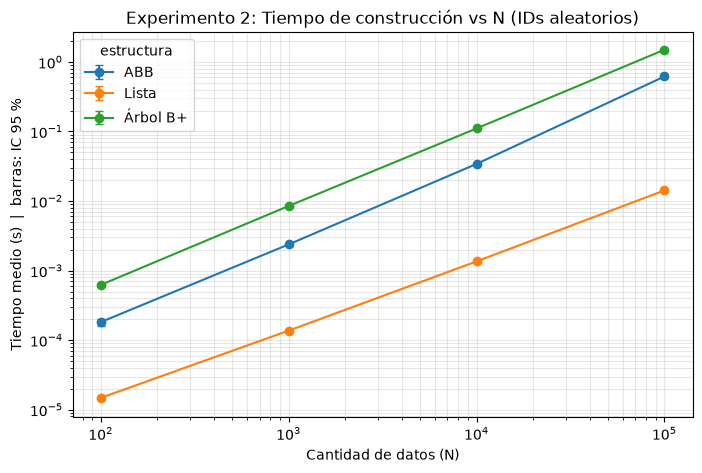


=== PENDIENTES LOG-LOG (Exponente b) ===
Estructura: ABB        | Pendiente (b): 1.1749
Estructura: Lista      | Pendiente (b): 0.9941
Estructura: Árbol B+   | Pendiente (b): 1.1256


,estructura,N,n,media,desviacion,mediana,iqr,ic_inf,ic_sup,atipicos,n_sin,media_sin,desviacion_sin,mediana_sin,iqr_sin,ic_inf_sin,ic_sup_sin
0,ABB,100,30,1.819433e+05,5.326173e+04,1.702500e+05,11500.0,1.620551e+05,2.018316e+05,2,28,1.711429e+05,7.813304e+03,1.699000e+05,8925.0,1.681132e+05,1.741725e+05
1,ABB,1000,30,2.379207e+06,1.962605e+05,2.335850e+06,138475.0,2.305922e+06,2.452492e+06,1,29,2.348410e+06,1.021043e+05,2.331600e+06,137700.0,2.309572e+06,2.387249e+06
2,ABB,10000,30,3.416592e+07,2.266399e+06,3.342915e+07,3186500.0,3.331963e+07,3.501221e+07,0,30,3.416592e+07,2.266399e+06,3.342915e+07,3186500.0,3.331963e+07,3.501221e+07
3,ABB,100000,30,6.174642e+08,1.774322e+07,6.115320e+08,12774225.0,6.108388e+08,6.240897e+08,2,28,6.138772e+08,1.043338e+07,6.111913e+08,12261175.0,6.098316e+08,6.179229e+08
4,Lista,100,30,1.482333e+04,2.188005e+03,1.440000e+04,475.0,1.400632e+04,1.564035e+04,1,29,1.442759e+04,3.034287e+02,1.440000e+04,500.0,1.431217e+04,1.454300e+04
5,Lista,1000,30,1.371300e+05,8.042137e+03,1.351000e+05,4525.0,1.341270e+05,1.401330e+05,3,27,1.348778e+05,2.838517e+03,1.349000e+05,3000.0,1.337549e+05,1.360007e+05
6,Lista,10000,30,1.356343e+06,1.459659e+05,1.312150e+06,55350.0,1.301839e+06,1.410848e+06,4,26,1.309715e+06,3.481710e+04,1.305800e+06,40700.0,1.295652e+06,1.323778e+06
7,Lista,100000,30,1.421805e+07,1.056535e+06,1.408475e+07,1347125.0,1.382353e+07,1.461256e+07,0,30,1.421805e+07,1.056535e+06,1.408475e+07,1347125.0,1.382353e+07,1.461256e+07
8,Árbol B+,100,30,6.235167e+05,3.049425e+04,6.233000e+05,24050.0,6.121299e+05,6.349034e+05,3,27,6.157444e+05,1.806359e+04,6.224000e+05,24550.0,6.085987e+05,6.228902e+05
9,Árbol B+,1000,30,8.493887e+06,6.096973e+05,8.294000e+06,244375.0,8.266222e+06,8.721551e+06,3,27,8.318300e+06,1.887621e+05,8.262800e+06,198250.0,8.243628e+06,8.392972e+06


In [12]:
# Escritas con asistencia de IA (Claude, Anthropic, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3. Estructura basada en el Experimento 1.

import pandas as pd

# Importar las clases de las estructuras de datos
from ABB import ABB
from ArbolBPlus import ArbolBPlus
from GestorListaEstudiantes import GestorListaEstudiantes

# Importar funciones de generación y medición
from funciones_auxiliares import generar_estudiantes, medir_construccion


# 1. Configuración de parámetros (los mismos del E1)
TAMANOS_N = [100, 1_000, 10_000, 100_000]
REPETICIONES = 30
CALENTAMIENTO = 3
SEMILLA_BASE = 1000
ORDEN_BPLUS = 4

# Cómo se crea cada estructura VACÍA. Se usa lambda para que cada llamada cree una nueva
# (así la lista nunca reutiliza datos de una construcción anterior).
crear_estructura = {
    "Lista": lambda: GestorListaEstudiantes([]),
    "ABB": lambda: ABB(),
    "Árbol B+": lambda: ArbolBPlus(ORDEN_BPLUS),
}

mediciones_crudas = []   # aquí se guarda una fila por cada medición


# 2. Bucle experimental (una semilla distinta por repetición)
for n in TAMANOS_N:
    print(f"Ejecutando pruebas para N = {n:,}...")

    for i in range(REPETICIONES):
        semilla_estudiantes = SEMILLA_BASE + i

        # Paso A: generar los estudiantes (IDs aleatorios). Las tres estructuras reciben los mismos.
        estudiantes = generar_estudiantes(n, ordenados=False, semilla=semilla_estudiantes)

        # Paso B: para cada estructura, calentar y medir cuánto tarda en construirse
        for nombre, crear in crear_estructura.items():

            # Calentamiento: se construye 3 veces y se descartan los tiempos
            for _ in range(CALENTAMIENTO):
                medir_construccion(crear, estudiantes)

            # Medición real: tiempo de insertar los N estudiantes, uno por uno, en una estructura vacía
            tiempo_ns, _ = medir_construccion(crear, estudiantes)

            mediciones_crudas.append({
                "N": n,
                "repeticion": i,
                "semilla": semilla_estudiantes,
                "estructura": nombre,
                "tiempo_ns": tiempo_ns
            })


# 3. Exportación a CSV y resumen estadístico
df_crudas = pd.DataFrame(mediciones_crudas)
ruta_crudas = guardar_csv(df_crudas, "e2_mediciones_crudas")

df_resumen = resumir_tabla(df_crudas, columna_curva="estructura", columna_x="N")
ruta_resumen = guardar_csv(df_resumen, "e2_construccion_vs_n")

print(f"\n¡Pruebas finalizadas!")
print(f"Mediciones crudas guardadas en: {ruta_crudas}")
print(f"Resumen estadístico guardado en: {ruta_resumen}")


# 4. Gráfica del tiempo total de construcción
graficar(
    resumen=df_resumen,
    columna_curva="estructura",
    columna_x="N",
    titulo="Experimento 2: Tiempo de construcción vs N (IDs aleatorios)",
    etiqueta_x="Cantidad de datos (N)",
    unidad="s",
    escala_log=True
)

# 5. Pendientes log-log (exponente b), mismo formato del E1
print("\n=== PENDIENTES LOG-LOG (Exponente b) ===")
for estructura in df_resumen["estructura"].unique():
    df_est = df_resumen[df_resumen["estructura"] == estructura]
    pendiente = pendiente_loglog(df_est["N"], df_est["media"])
    print(f"Estructura: {estructura:10s} | Pendiente (b): {pendiente:.4f}")

display(df_resumen)   # tabla de resumen estadístico

### Análisis del experimento 2

La siguiente tabla resume el tiempo medio acumulado para construir cada estructura completa. Para facilitar la comparación, todos los valores se expresan en milisegundos ($\text{ms}$), agregando su equivalente en segundos ($\text{s}$) en los tamaños más grandes:

| Estructura |  N = 100 | N = 1000 | N = 10000 |          N = 100000 | Pendiente (b) | Crecimiento empírico                       |
| ---------- | -------: | --------: | ---------: | -------------------: | ------------: | ------------------------------------------ |
| Lista      | 0.015 ms |  0.137 ms |   1.356 ms |             14.22 ms |        0.9941 | Lineal, compatible con $O(N)$           |
| ABB        | 0.182 ms |  2.379 ms |   34.17 ms |   617.46 ms (0.62 s) |        1.1749 | Superlineal, compatible con $(N\log N)$ |
| Árbol B+   | 0.624 ms |  8.494 ms |  110.52 ms | 1497.92 ms (1.50 s) |        1.1256 | Superlineal, compatible con $O(N\log N)$ |

De la tabla, se pueden describir las siguientes observaciones:
1. La pendiente Log-Log de la lista es igual a 0.9941, que se aproxima a 1.0. De acuerdo con este resultado, el comportamiento de la lista concuerda con un crecimiento lineal. Debido a que la implementación utiliza el método **append** de Python, cada inserción cuesta $O(1)$, por lo que realizar N inserciones cuesta $O(N)$.
2. El árbol B+ tuvo una pendiente igual a 1.1256, este valor deja de ser compatible con la complejidad lineal. Sin embargo, indica un crecimiento superlineal, más alineado con una complejidad $O(N\log N)$. Esta conclusión concuerda con la implementación utilizada en este laboratorio, ya que el proceso de inserción requiere descender hasta las hojas, que teóricamente tiene complejidad $O(\log N)$ y hacer esto para $N$ datos (estudiantes) cuesta N veces $O(\log N)$, es decir, $O(N\log N)$.
3. El árbol ABB presenta la mayor pendiente de las tres estructuras (1.1749). Al igual que el Árbol B+, su crecimiento es compatible con $O(N \log N)$. Sin embargo, dentro del rango probado, el costo de construcción del ABB aumenta a un ritmo ligeramente mayor que el del Árbol B+.

#### Tiempo promedio de inserción por estudiante

Al dividir el tiempo total entre la cantidad de datos $N$, podemos medir cuánto tiempo cuesta insertar un único estudiante. En esta tabla utilizamos microsegundos ($\mu\text{s}$), donde ($1 \ \mu\text{s} = 0.001 \text{ ms}$):

| Estructura | N=100            | N=1000          | N=10000           | N=100000          |
| -------------- | --------------------- | --------------------- | ---------------------- | ---------------------- |
| **Lista**      | $0.148 \ \mu\text{s}$ | $0.137 \ \mu\text{s}$ | $0.136 \ \mu\text{s}$  | $0.142 \ \mu\text{s}$  |
| **ABB**        | $1.819 \ \mu\text{s}$ | $2.379 \ \mu\text{s}$ | $3.417 \ \mu\text{s}$  | $6.175 \ \mu\text{s}$  |
| **Árbol B+**   | $6.235 \ \mu\text{s}$ | $8.494 \ \mu\text{s}$ | $11.052 \ \mu\text{s}$ | $14.979 \ \mu\text{s}$ |


Realizando el análisis de las pendientes y comparando con los tiempos de inserción de un estudiante por cada tamaño N:
1. La lista, de nuevo, muestra que el tiempo de inserción es prácticamente constante ($\approx 0.14 \ \mu\text{s}$).
2. En **ambos árboles**, el costo individual crece a medida que aumenta N, pero se observan dos diferencias fundamentales:
    - El árbol B+, al tener una pendiente más pequeña, presenta un crecimiento más lento entre sus tiempos absolutos. Por ejemplo, la diferencia entre $N = 100$ y $N = 100000$ es de un factor de $2.4$ aproximadamente.
    - Por otro lado, el árbol binario de búsqueda presenta un crecimiento más rápido entre sus tiempos absolutos. Para el mismo ejemplo, el factor es de $3.4$.

#### Respecto a las diferencias observadas entre los dos árboles (B+ y ABB)

Aunque ambos árboles tienen un crecimiento global $O(N \log N)$, el Árbol B+ fue más lento en tiempo absoluto en todas las pruebas, pero su tiempo creció a un ritmo menor (menor pendiente). La razón detrás de esto puede deberse a la sobrecarga de trabajo de la implementación del árbol B+ frente a la del árbol binario de búsqueda:
1. En el ABB, insertar solo requiere comparar las claves de búsqueda (los ID), crear un nodo y enlazarlo al resto del árbol.
2. En el Árbol B+, además de buscar la hoja, la implementación debe insertar el dato en listas internas de claves y punteros. Cuando un nodo se llena, el algoritmo debe copiar listas, crear un nuevo nodo, redistribuir las claves (dividir) y actualizar enlaces. Todo este trabajo adicional en memoria hace que cada inserción sea más pesada en escala absoluta.

Asimismo, la pendiente Log-Log menor en el árbol B+ se debe principalmente a que este presenta una altura inferior al árbol binario, la cual aumenta mucho más despacio. Por esa razón, el incremento de tiempo para procesar tamaños de entrada más grandes es menor en el Árbol B+. Este resultado coincide directamente con la teoría, ya que:

Altura del árbol binario balanceado:
$$
h_{\text{binario}} = \log_2(N)
$$

Altura del Árbol B+ (peor caso con capacidad máxima $n$):
$$
h_{\text{B+}} = \log_{\lceil n/2 \rceil}(N)
$$

1. Aplicamos la regla del cambio de base logarítmica
   $\left(\log_b(A) = \frac{\log_2(A)}{\log_2(b)}\right)$ a la fórmula del Árbol B+:

   $$
   h_{\text{B+}} = \frac{\log_2(N)}{\log_2(\lceil n/2 \rceil)}
   $$

2. Sustituimos $\log_2(N)$ por $h_{\text{binario}}$:

   $$
   h_{\text{B+}} = \frac{h_{\text{binario}}}{\log_2(\lceil n/2 \rceil)}
   $$

Por lo tanto:

$$
\boxed{h_{\text{B+}} = \frac{h_{\text{binario}}}{\log_2(\lceil n/2 \rceil)}}
$$

Es decir, la altura del árbol B+ es, como se esperaba, una fracción de la del árbol binario. Este resultado concuerda con las observaciones experimentales.

#### Observaciones sobre los datos atípicos e intervalos de confianza

1. Los intervalos de confianza no muestran solapamiento. En su lugar, presentan diferencias entre los tiempos medios ya desde los $N = 100$ estudiantes.
2. Al comparar la media general con la media sin atípicos (media_sin), no se observan diferencias significativas para cada estructura y tamaño. Por ejemplo, en $N = 100.000$, el tiempo del Árbol B+ pasa de $15.03 \text{ ms}$ a $14.69 \text{ ms}$, y el del ABB pasa de $8.48 \text{ ms}$ a $8.32 \text{ ms}$. Las mediciones obtenidas pueden considerarse estables.


## Experimento 3: Tiempo de construcción vs N (ID's ordenados)

> Sección redactada con asistencia de IA (Gemini, Google, octubre 2026) y revisada por Daniel Sánchez Escobar.

**Pregunta.** ¿Cómo se degrada el rendimiento de las tres estructuras cuando los datos ingresan estrictamente ordenados de menor a mayor? ¿En qué punto exacto el ABB pierde su comportamiento logarítmico y cómo responde el Árbol B+?

**Hipótesis.** Al recibir datos ordenados ($1, 2, 3, \dots, N$), el ABB se degrada a una lista enlazada (línea recta a la derecha), alcanzando un tiempo de construcción cuadrático de $O(N^2)$. El Árbol B+, al ser auto-balanceado, conservará su crecimiento de $O(N \log N)$ dividiendo sus nodos cuando se llenan. La Lista continuará con un tiempo de inserción al final constante de $O(1)$ y un tiempo de construcción lineal $O(N)$.

### Diseño:

1. Se evalúan los tamaños $N \in \{100, 1.000, 10.000\}$. Se omite $N = 100.000$ en este experimento para evitar tiempos de ejecución inviables en el ABB.
2. Se utiliza generar_estudiantes(n, ordenados=True, semilla=...) para garantizar IDs secuenciales ($1, 2, 3, \dots, N$).
3. Se mide el tiempo acumulado de inserción uno a uno en nanosegundos, con $3$ pasadas de calentamiento y $30$ repeticiones.

#### Variables del experimento:
| Variable | Configuración | Significado |
|---|---|---|
| **Tamaños ($N$)** | $100, 1000, 10000$ | Cantidad de registros a insertar. |
| **Patrón de IDs** | Ordenados (`ordenados=True`) | Los datos llegan ordenados de menor a mayor ($1$ a $N$). |
| **Estructuras** | Lista, ABB, Árbol B+ | Algoritmos a comparar. |
| **Orden B+ ($n$)** | $4$ | Límite de punteros por nodo del Árbol B+. |
| **Repeticiones** | $30$ ejecuciones | Corridas independientes con calentamiento. |


Ejecutando pruebas para N = 100 con IDs ordenados...
Ejecutando pruebas para N = 1,000 con IDs ordenados...
Ejecutando pruebas para N = 10,000 con IDs ordenados...

¡Pruebas del Experimento 3 finalizadas exitosamente!
Mediciones crudas guardadas en: resultados/e3_mediciones_crudas.csv
Resumen estadístico guardado en: resultados/e3_construccion_ordenados_vs_n.csv



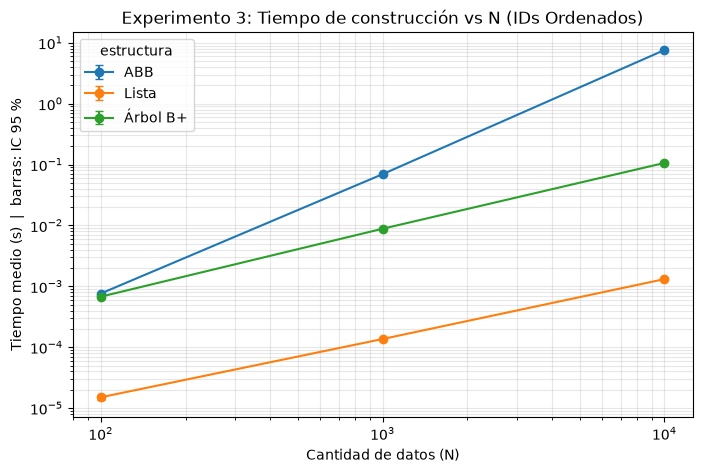

=== PENDIENTES LOG-LOG (Exponente b con datos ordenados) ===
Estructura: ABB        | Pendiente (b): 1.9993
Estructura: Lista      | Pendiente (b): 0.9704
Estructura: Árbol B+   | Pendiente (b): 1.0981


,estructura,N,n,media,desviacion,mediana,iqr,ic_inf,ic_sup,atipicos,n_sin,media_sin,desviacion_sin,mediana_sin,iqr_sin,ic_inf_sin,ic_sup_sin
0,ABB,100,30,7.619900e+05,2.417935e+04,7.575000e+05,14750.0,7.529613e+05,7.710187e+05,3,27,7.580741e+05,1.182421e+04,7.565000e+05,13050.0,7.533966e+05,7.627516e+05
1,ABB,1000,30,6.950897e+07,5.717584e+06,6.833450e+07,1343300.0,6.737399e+07,7.164395e+07,2,28,6.837554e+07,1.007273e+06,6.816380e+07,1282600.0,6.798496e+07,6.876612e+07
2,ABB,10000,30,7.594075e+09,3.804955e+08,7.535037e+09,482601775.0,7.451996e+09,7.736154e+09,1,29,7.556375e+09,3.252476e+08,7.510636e+09,480635300.0,7.432657e+09,7.680093e+09
3,Lista,100,30,1.505667e+04,3.312535e+03,1.440000e+04,475.0,1.381975e+04,1.629359e+04,2,28,1.438214e+04,2.919330e+02,1.440000e+04,400.0,1.426894e+04,1.449534e+04
4,Lista,1000,30,1.363433e+05,2.776711e+03,1.365000e+05,3225.0,1.353065e+05,1.373802e+05,1,29,1.365724e+05,2.520898e+03,1.365000e+05,3000.0,1.356135e+05,1.375313e+05
5,Lista,10000,30,1.313830e+06,4.837602e+04,1.304400e+06,43050.0,1.295766e+06,1.331894e+06,1,29,1.307679e+06,3.533209e+04,1.299200e+06,39200.0,1.294240e+06,1.321119e+06
6,Árbol B+,100,30,6.762000e+05,9.221591e+04,6.479000e+05,14575.0,6.417660e+05,7.106340e+05,4,26,6.486500e+05,7.986251e+03,6.471500e+05,6525.0,6.454243e+05,6.518757e+05
7,Árbol B+,1000,30,8.826107e+06,5.417632e+05,8.631000e+06,182950.0,8.623809e+06,9.028404e+06,5,25,8.605800e+06,1.087382e+05,8.587800e+06,156000.0,8.560915e+06,8.650685e+06
8,Árbol B+,10000,30,1.062342e+08,9.794965e+05,1.061268e+08,1205150.0,1.058685e+08,1.066000e+08,0,30,1.062342e+08,9.794965e+05,1.061268e+08,1205150.0,1.058685e+08,1.066000e+08


In [7]:
# Escritas con asistencia de IA (Gemini, Google, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3. Estructura basada en los experimentos anteriores.

import pandas as pd

# Importar las clases de las estructuras de datos
from ABB import ABB
from ArbolBPlus import ArbolBPlus
from GestorListaEstudiantes import GestorListaEstudiantes

# Importar funciones de generación y medición
from funciones_auxiliares import generar_estudiantes, medir_construccion


# Se limita a 10.000 para evitar el número elevado de horas de ejecución que tomaría N=100.000 en el ABB
TAMANOS_N_ORDENADOS = [100, 1_000, 10_000]
REPETICIONES = 30
CALENTAMIENTO = 3
SEMILLA_BASE = 1000
ORDEN_BPLUS = 4

# Funciones generadoras para instanciar estructuras vacías en cada prueba
crear_estructura = {
    "Lista": lambda: GestorListaEstudiantes([]),
    "ABB": lambda: ABB(),
    "Árbol B+": lambda: ArbolBPlus(ORDEN_BPLUS),
}

mediciones_crudas = []  # Guarda una fila por cada medición

for n in TAMANOS_N_ORDENADOS:
    print(f"Ejecutando pruebas para N = {n:,} con IDs ordenados...")

    for i in range(REPETICIONES):
        semilla_estudiantes = SEMILLA_BASE + i

        # Generar estudiantes con IDs estrictamente ORDENADOS (1, 2, ..., N)
        estudiantes_ordenados = generar_estudiantes(n, ordenados=True, semilla=semilla_estudiantes)

        for nombre, crear in crear_estructura.items():

            # Pasadas de calentamiento descartadas para acondicionar la caché
            for _ in range(CALENTAMIENTO):
                medir_construccion(crear, estudiantes_ordenados)

            # Medición oficial: tiempo acumulado de insertar N elementos ordenados
            tiempo_ns, _ = medir_construccion(crear, estudiantes_ordenados)

            mediciones_crudas.append({
                "N": n,
                "repeticion": i + 1,
                "semilla": semilla_estudiantes,
                "estructura": nombre,
                "patron_datos": "Ordenados",
                "tiempo_ns": tiempo_ns
            })


# 3. EXPORTACIÓN A CSV Y RESUMEN ESTADÍSTICO
df_crudas = pd.DataFrame(mediciones_crudas)
ruta_crudas = guardar_csv(df_crudas, "e3_mediciones_crudas")

df_resumen = resumir_tabla(df_crudas, columna_curva="estructura", columna_x="N")
ruta_resumen = guardar_csv(df_resumen, "e3_construccion_ordenados_vs_n")

print(f"\n¡Pruebas del Experimento 3 finalizadas exitosamente!")
print(f"Mediciones crudas guardadas en: {ruta_crudas}")
print(f"Resumen estadístico guardado en: {ruta_resumen}\n")

# 4. VISUALIZACIÓN Y CÁLCULO DE PENDIENTES

# Gráfica del tiempo de construcción vs N en escala log-log
graficar(
    resumen=df_resumen,
    columna_curva="estructura",
    columna_x="N",
    titulo="Experimento 3: Tiempo de construcción vs N (IDs Ordenados)",
    etiqueta_x="Cantidad de datos (N)",
    unidad="s",
    escala_log=True
)

# Cálculo e impresión de pendientes log-log
print("=== PENDIENTES LOG-LOG (Exponente b con datos ordenados) ===")
for estructura in df_resumen["estructura"].unique():
    df_est = df_resumen[df_resumen["estructura"] == estructura]
    pendiente = pendiente_loglog(df_est["N"], df_est["media"])
    print(f"Estructura: {estructura:10s} | Pendiente (b): {pendiente:.4f}")

display(df_resumen)

### Análisis del experimento 3

A diferencia de los datos aleatorios del Experimento 2, el orden inicial permitió observar alteraciones en los tiempos de construcción medios y en las tasas de crecimiento de los algoritmos, particularmente en el árbol binario de búsqueda (ABB). Para ello, se realiza una descripción cualitativa de la gráfica y de los resultados.

En la gráfica se pueden observar los siguientes comportamientos:
1. La lista presenta los tiempos medios de construcción absolutos más bajos.
2. El árbol B+ y el árbol binario de búsqueda inician parejos cuando $N = 100$ y en la medida que aumenta $N$, se hace más marcada la diferencia de crecimientos en los tiempos.
3. De acuerdo con el punto previo, se observa que el árbol binario de búsqueda tuvo tanto los tiempos más altos como la curva más empinada.

Ahora, consideremos la siguiente tabla que resume los tiempos medios obervados, en milisegundos para facilitar la lectura:

| Estructura | N=100          | N=1000         | N=10000                             | Pendiente (b) | Crecimiento empírico                  |
| -------------- | ------------------ | ------------------ | --------------------------------------- | ----------------- | ----------------------------------------- |
| **Lista**      | $0.015 \text{ ms}$ | $0.136 \text{ ms}$ | $1.314 \text{ ms}$                      | $0.9704$          | Lineal, compatible con $O(N)$             |
| **Árbol B+**   | $0.676 \text{ ms}$ | $8.826 \text{ ms}$ | $106.23 \text{ ms}$ ($0.11 \text{ s}$)  | $1.0981$          | Superlineal, compatible con $O(N \log N)$ |
| **ABB**        | $0.762 \text{ ms}$ | $69.51 \text{ ms}$ | $7594.07 \text{ ms}$ ($7.59 \text{ s}$) | $1.9993$          | Cuadrático, compatible con $O(N^2)$       |

De los resultados de la tabla, se puede inferir que:
1. El valor de la pendiente en la lista fue de $0.9704$, lo que la hace compatible con un comportamiento lineal $O(N)$. Este resultado es de esperarse, pues la implementación utiliza el método append de Python que sirve para insertar al final de la lista y, para $N$ inserciones, se llega justamente al órden de magnitud $N$. En consecuencia, el resultado es consistente con las observaciones del experimento 2 y confirma, experimentalmente, que la inserción en la lista no se ve afectada por el órden de los datos.
2. De manera similar, el resultado de la pendiente para el árbol B+ fue de $1.0981$, similar a los resultados obtenidos en el experimento 2. De ahí, se infiere que el árbol B+ sigue tieniendo una complejidad superlienal consistente con el órden $O(N\log N)$.
3. El árbol binario de búsqueda presentó los mayores cambios con respecto al experimento anterior. Su pendiente ($1.993$) se aproxima a $2.0$, lo que lo hace compatible con un comportamiento asintótico cuadrático $O(N^{2})$, mostrando así una degradación del comportamiento superlineal del experimento anterior.
4. De acuerdo con lo previamente dicho, el árbol binario presenta consistentemente los mayores tiempos de construcción, probablemente por el hecho de que por cada inserción, necesita recorrer todos los nodos anteriores.

#### Tiempo promedio de inserción por estudiante

Al dividir el tiempo total entre la cantidad de datos $N$, podemos medir cuánto tiempo cuesta insertar un único estudiante. En esta tabla utilizamos microsegundos ($\mu\text{s}$), donde ($1 \ \mu\text{s} = 0.001 \text{ ms}$):

| Estructura | N=100             | N=1000             | N=10000             |
| -------------- | --------------------- | ---------------------- | ----------------------- |
| **Lista**      | $0.151 \ \mu\text{s}$ | $0.136 \ \mu\text{s}$  | $0.131 \ \mu\text{s}$   |
| **Árbol B+**   | $6.762 \ \mu\text{s}$ | $8.826 \ \mu\text{s}$  | $10.623 \ \mu\text{s}$  |
| **ABB**        | $7.620 \ \mu\text{s}$ | $69.509 \ \mu\text{s}$ | $759.407 \ \mu\text{s}$ |

1. En la Lista el costo por estudiante se mantiene aproximadamente constante.
2. En el Árbol B+ el costo unitario aumenta muy lentamente (de $6.76 \ \mu\text{s}$ a $10.62 \ \mu\text{s}$), dado que la altura del árbol permanece logarítmica.
3. En el ABB ocurre un mayor incremento. Insertar un estudiante en $N = 10000$ toma $759.41 \ \mu\text{s}$, lo que representa un costo $100$ veces mayor (aproximadamente) que en $N = 100$. Esto sucede porque cada nueva inserción debe recorrer una cadena cada vez más larga de nodos previa a la inserción.

#### Valores atípicos e intervalos de confianza.
1. En $N = 100$, los intervalos del ABB y del Árbol B+ se encuentran muy próximos (aunque sin estar solapados), pero a partir de $N = 1.000$ la separación es notable y sin solapamiento, siendo esto una señal más de la degeneración cuadrática del ABB.
2. Se registraron únicamente entre $0$ y $5$ valores atípicos por cada grupo de $30$ repeticiones. En general, las medias con y sin datos atípicos no presentan diferencias notables. Lo mismo puede decirse al comparar cada mediana con su respectiva media aritmética. Por lo que es posible afirmar que el ruido externo no jugó un papel importante en la medición e identificación de tendencias.


## Experimento 4: relación entre la altura y el tiempo de búsqueda en árboles B+ y ABB

> Sección redactada con asistencia de IA (Gemini, Google, octubre 2026) y revisada por Daniel Sánchez Escobar.

**Pregunta.** ¿Cómo influye la altura ($H$) de un árbol en el tiempo necesario para resolver $M = 1.000$ búsquedas? ¿Por qué el Árbol B+ logra mantener una menor altura y mejores tiempos de búsqueda que el ABB a medida que aumenta $N$?

**Hipótesis.** Para buscar un registro dentro de un árbol se debe descender desde la raíz hasta las hojas; por lo tanto, a mayor altura $H$, mayor será la cantidad de saltos en memoria y comparaciones requeridas. El Árbol B+, al almacenar múltiples claves dentro de un mismo nodo, mantendrá una altura compacta, lo que resultará en tiempos de búsqueda significativamente menores frente al ABB, cuya altura crece más rápido.

### Diseño:

1. Se evalúan los tamaños $N \in \{100, 1.000, 10.000, 100.000\}$ insertando datos con IDs no secuenciales (aleatorios) para construir un ABB y un Árbol B+ ($n = 4$).
2. Por cada estructura y tamaño $N$, se consulta y registra la altura exacta $H$ obtenida tras la construcción mediante el método `.altura()`.
3. Se genera un conjunto de $M = 1.000$ consultas de búsqueda ($80\%$ de IDs existentes y $20\%$ de inexistentes) y se mide el tiempo total acumulado en nanosegundos para resolver las $1.000$ búsquedas, realizando $3$ pasadas de calentamiento y $30$ repeticiones oficiales por configuración.

#### Variables del experimento:

| Variable | Configuración | Significado |
| --- | --- | --- |
| **Tamaños ($N$)** | $100, 1000, 10000, 100000$ | Cantidad de registros almacenados en el árbol. |
| **Consultas ($M$)** | $1000$ búsquedas | Número de IDs a consultar ($80\%$ exitosos, $20\%$ fallidos). |
| **Estructuras** | ABB, Árbol B+ | Algoritmos basados en árboles a comparar. |
| **Orden B+ ($n$)** | $4$ | Factor de ramificación del Árbol B+. |
| **Altura ($H$)** | Entero ($1, 2, 3, \dots$) | Cantidad de niveles del árbol desde la raíz. |
| **Repeticiones** | $30$ ejecuciones | Corridas independientes con $3$ pasadas de calentamiento. |

Procesando N = 100 elementos...
Procesando N = 1,000 elementos...
Procesando N = 10,000 elementos...
Procesando N = 100,000 elementos...

¡Experimento 4 finalizado con éxito!
Mediciones guardadas en: resultados/e4_mediciones_crudas.csv
Resumen guardado en: resultados/e4_tiempo_busqueda_vs_n.csv

=== ALTURA PROMEDIO MEDIDA EN CADA ÁRBOL ===
estructura      N    altura
       ABB    100 13.033333
       ABB   1000 22.133333
       ABB  10000 30.800000
       ABB 100000 40.333333
  Árbol B+    100  4.733333
  Árbol B+   1000  6.966667
  Árbol B+  10000  9.000000
  Árbol B+ 100000 11.000000




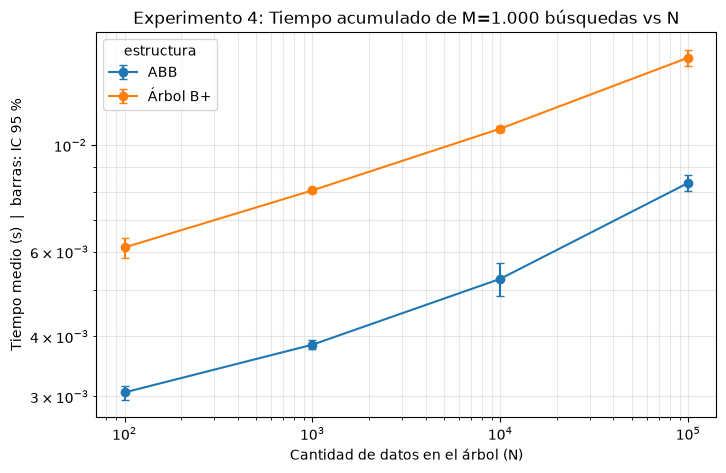

,estructura,N,n,media,desviacion,mediana,iqr,ic_inf,ic_sup,atipicos,n_sin,media_sin,desviacion_sin,mediana_sin,iqr_sin,ic_inf_sin,ic_sup_sin
0,ABB,100,30,3.058590e+06,2.747628e+05,2972850.0,173725.0,2.955992e+06,3.161188e+06,3,27,2.975500e+06,101701.070261,2963400.0,115150.0,2.935268e+06,3.015732e+06
1,ABB,1000,30,3.844493e+06,2.329249e+05,3813100.0,211075.0,3.757518e+06,3.931469e+06,2,28,3.794993e+06,126000.775802,3794450.0,210400.0,3.746135e+06,3.843851e+06
2,ABB,10000,30,5.270910e+06,1.093756e+06,4959600.0,838225.0,4.862495e+06,5.679325e+06,2,28,5.028682e+06,609601.390135,4875750.0,740675.0,4.792303e+06,5.265061e+06
3,ABB,100000,30,8.345470e+06,8.358016e+05,7991300.0,1078750.0,8.033377e+06,8.657563e+06,1,29,8.269938e+06,739085.705650,7980100.0,986700.0,7.988805e+06,8.551071e+06
4,Árbol B+,100,30,6.126377e+06,7.742786e+05,6020750.0,322650.0,5.837256e+06,6.415497e+06,9,21,5.937133e+06,246766.850151,6017600.0,127300.0,5.824806e+06,6.049460e+06
5,Árbol B+,1000,30,8.052723e+06,2.445496e+05,8067750.0,249750.0,7.961407e+06,8.144040e+06,1,29,8.078203e+06,204371.493824,8073200.0,229200.0,8.000465e+06,8.155942e+06
6,Árbol B+,10000,30,1.082236e+07,4.105901e+05,10742150.0,537900.0,1.066904e+07,1.097567e+07,0,30,1.082236e+07,410590.143560,10742150.0,537900.0,1.066904e+07,1.097567e+07
7,Árbol B+,100000,30,1.520422e+07,1.617636e+06,14535950.0,1213600.0,1.460018e+07,1.580826e+07,3,27,1.473806e+07,658205.633206,14525400.0,1067250.0,1.447768e+07,1.499844e+07


In [ ]:
# Escritas con asistencia de IA (Gemini, Google, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3. Estructura basada en los experimentos anteriores.
import pandas as pd

# Importamos las clases de los dos árboles que vamos a comparar
from ABB import ABB
from ArbolBPlus import ArbolBPlus

# Importamos las funciones para generar datos y medir tiempos
from funciones_auxiliares import (
    generar_estudiantes,
    generar_ids_busqueda,
    medir_busquedas
)


# 1. CONFIGURACIÓN DE PARÁMETROS
TAMANOS_N = [100, 1_000, 10_000, 100_000] # Cantidad de datos a insertar
CANTIDAD_M_BUSQUEDAS = 1_000               # M = 1.000 búsquedas por experimento
REPETICIONES = 30                          # 30 ejecuciones para validez estadística
CALENTAMIENTO = 3                         # 3 ejecuciones previas descartadas
SEMILLA_BASE = 1000                        # Semilla para reproductibilidad
ORDEN_BPLUS = 4                            # Factor de ramificación del Árbol B+

# Definimos cómo instanciar cada árbol vacío
crear_arboles = {
    "ABB": lambda: ABB(),
    "Árbol B+": lambda: ArbolBPlus(ORDEN_BPLUS)
}

mediciones_crudas = [] # Guardará cada medición individual
resumen_alturas = []   # Guardará la altura promedio medida en cada N


# 2. BUCLE EXPERIMENTAL
for n in TAMANOS_N:
    print(f"Procesando N = {n:,} elementos...")

    for i in range(REPETICIONES):
        semilla_actual = SEMILLA_BASE + i

        # Paso A: Generar N estudiantes aleatorios
        estudiantes = generar_estudiantes(n, ordenados=False, semilla=semilla_actual)

        # Paso B: Generar M IDs para buscar (80% existentes, 20% no existentes)
        ids_busqueda = generar_ids_busqueda(
            estudiantes, 
            cantidad_m=CANTIDAD_M_BUSQUEDAS, 
            proporcion_existentes=0.8, 
            semilla=semilla_actual
        )

        for nombre, crear in crear_arboles.items():
            # Construir el árbol e insertar los N estudiantes
            arbol = crear()
            arbol.construir_arbol(estudiantes)

            # Obtener la altura del árbol construido
            h = arbol.altura()

            # Guardar registro de la altura observada
            resumen_alturas.append({
                "N": n,
                "estructura": nombre,
                "altura": h
            })

            # Pasadas de calentamiento (no se registran sus tiempos)
            for _ in range(CALENTAMIENTO):
                medir_busquedas(arbol, ids_busqueda)

            # Medición oficial: tiempo acumulado para resolver M búsquedas
            tiempo_ns = medir_busquedas(arbol, ids_busqueda)

            # Guardar la medición cruda
            mediciones_crudas.append({
                "N": n,
                "repeticion": i + 1,
                "semilla": semilla_actual,
                "estructura": nombre,
                "altura": h,
                "tiempo_ns": tiempo_ns
            })



# 3. PROCESAMIENTO Y GUARDADO DE RESULTADOS
# Convertir a DataFrames de Pandas
df_crudas = pd.DataFrame(mediciones_crudas)
df_alturas = pd.DataFrame(resumen_alturas)

# Guardar mediciones crudas en CSV
ruta_crudas = guardar_csv(df_crudas, "e4_mediciones_crudas")

# Calcular tabla de resumen estadístico para los tiempos de búsqueda
df_resumen_tiempos = resumir_tabla(df_crudas, columna_curva="estructura", columna_x="N")
ruta_resumen = guardar_csv(df_resumen_tiempos, "e4_tiempo_busqueda_vs_n")

# Calcular la altura promedio por cada estructura y tamaño N
df_promedio_alturas = df_alturas.groupby(["estructura", "N"])["altura"].mean().reset_index()

print(f"\n¡Experimento 4 finalizado con éxito!")
print(f"Mediciones guardadas en: {ruta_crudas}")
print(f"Resumen guardado en: {ruta_resumen}\n")



# 4. MOSTRAR ALTURAS PROMEDIO MEDIDAS
print("=== ALTURA PROMEDIO MEDIDA EN CADA ÁRBOL ===")
print(df_promedio_alturas.to_string(index=False))
print("\n")


# 5. GRAFICAR TIEMPO DE BÚSQUEDA VS N

graficar(
    resumen=df_resumen_tiempos,
    columna_curva="estructura",
    columna_x="N",
    titulo="Experimento 4: Tiempo acumulado de M=1.000 búsquedas vs N",
    etiqueta_x="Cantidad de datos en el árbol (N)",
    unidad="s",  # Mostramos en microsegundos (us) para mayor claridad
    escala_log=True
)

display(df_resumen_tiempos)

### Análisis del experimento 4

Los resultados experimentales muestran una relación consistente entre la altura de los árboles y el tiempo necesario para resolver $M = 1.000$ búsquedas. En ambas estructuras, a medida que la cantidad de datos ($N$) aumenta, también lo hace la altura promedio y el tiempo de búsqueda.

La siguiente tabla resume los tiempos medios observados y las alturas promedio calculadas:
| Estructura | Variable           | N=100         | N=1000       | N=10000       | N=100.000      |
| -------------- | ---------------------- | ----------------- | ----------------- | ------------------ | ------------------ |
| **ABB**        | **Altura promedio**    | $13.03$           | $22.13$           | $30.80$            | $40.33$            |
| **ABB**        | **Tiempo de búsqueda** | $3.06 \text{ ms}$ | $3.84 \text{ ms}$ | $5.27 \text{ ms}$  | $8.35 \text{ ms}$  |
| **Árbol B+**   | **Altura promedio**    | $4.73$            | $6.97$            | $9.00$             | $11.00$            |
| **Árbol B+**   | **Tiempo de búsqueda** | $6.13 \text{ ms}$ | $8.05 \text{ ms}$ | $10.82 \text{ ms}$ | $15.20 \text{ ms}$ |

A partir de estos datos, se hacen las siguientes observaciones:

1. Para encontrar un registro, cualquiera de los dos algoritmos de árboles debe descender desde la raíz hasta el nivel correspondiente (en el caso del B+ debe ser hasta una hoja). Esta afirmación se confirma con los resultados experimentales, ya que el aumento de la altura coincide con el crecimiento el tiempo total (ya que implica procesar una mayor cantidad de niveles). Sin embargo, los datos demuestran que esta relación no es la única que influye, ya que el tiempo final promedio del árbol B+ para cada $N$ fue más lento que el tiempo del árbol binario, incluso teniendo alturas significativamente menores.
2. La observación anterior puede deberse principalmente a la forma como operan ambas implementaciones algorítmicas en el propio Python. El árbol B+ produce menos saltos entre nodos, pero igualmente requiere iterar y comparar internamente las claves dentro del nodo para decidir hacia qué puntero hijo debe acceder para descender. Por otro lado, el árbol binario consiste en una implementación más sencilla, cada nivel contiene una solo valor, reduciendo la búsqueda a una comparación binaria para continuar por uno de dos hijos. Esta sobrecarga particular del lenguaje de programación hace plausible la explicación del por qué el árbol B+ no fue más eficiente que el árbol binario.

### Valores atípicos e intervalos de confianza

1. Las bandas de confianza reflejan la variabilidad en las $30$ repeticiones. Aunque el Árbol B+ muestra una amplitud visualmente mayor en $N=100$ y $N=100000$. No obstante, los intervalos de ambas estructuras se mantienen completamente separados para todos los valores de $N$ (no hay solapamientos). Esto confirma que hay diferencias significativa en sus tiempos medios.
2. Al comparar las medias totales con las medias recalculadas excluyendo los valores atípicos, las diferencias son bajas en todas las configuraciones. La presencia de estos datos no altera la conclusión principal del experimento, los tiempos aumentan con $N$ y el ABB sostiene tiempos de búsqueda absolutos menores.

## Experimento 5: Búsqueda contra M, con N fijo

> Sección redactada con asistencia de IA (Gemini, Google, octubre 2026) y revisada por Daniel Sánchez Escobar.

**Pregunta.** ¿Cómo escala el tiempo total de búsqueda al aumentar la cantidad de consultas ($M$) manteniendo fija la cantidad de datos guardados ($N = 10000$)? ¿El tiempo acumulado crece de forma estrictamente lineal ($O(M)$) en todas las estructuras?

**Hipótesis.** Al mantener constante el tamaño de la estructura ($N = 10000$), el costo promedio de realizar una sola búsqueda permanece fijo. Por lo tanto, al ejecutar $M$ búsquedas secuenciales, el tiempo acumulado responderá a una relación lineal $O(M)$ en las tres estructuras (Lista, ABB y Árbol B+), obteniendo una pendiente log-log $b \approx 1.0$. Las estructuras diferirán únicamente en su tiempo absoluto (desplazamiento vertical de la curva) debido a la eficiencia individual de consulta de cada algoritmo.

### Diseño:
1. Se construye una única base de datos fija de $N = 10000$ estudiantes con IDs aleatorios no secuenciales y se carga en una Lista, un ABB y un Árbol B+ ($n = 4$).
2. Se evalúan diferentes cantidades de consultas $M \in \{100, 1000, 10000\}$, manteniendo una proporción de $80\%$ búsquedas exitosas y $20\%$ fallidas. Se decide tomar solo hasta $10000$ para evitar tiempos de ejecución del experimento inviables.
3. Se mide el tiempo total acumulado en nanosegundos para procesar las $M$ consultas en cada estructura, ejecutando $3$ pasadas de calentamiento y $30$ repeticiones oficiales por cada valor de $M$.

#### Variables del experimento:

| **Variable**          | **Configuración**          | **Significado**                                            |
| --------------------- | -------------------------- | ---------------------------------------------------------- |
| **Tamaño fijo ($N$)** | $10000$ registros         | Cantidad constante de estudiantes almacenados en memoria.  |
| **Consultas ($M$)**   | $100, 1000, 10000$ | Cantidad de búsquedas puntuales a ejecutar en cada prueba. |
| **Estructuras**       | Lista, ABB, Árbol B+       | Algoritmos a comparar.                                     |
| **Orden B+ ($n$)**    | $4$                        | Factor de ramificación del Árbol B+.                       |
| **Repeticiones**      | $30$ ejecuciones           |     Corridas independientes con $3$ pasadas de calentamiento.|                                                       |



Construyendo estructuras con N = 10000 estudiantes...
Procesando M = 100 búsquedas...
Procesando M = 1,000 búsquedas...
Procesando M = 10,000 búsquedas...

¡Experimento 5 finalizado con éxito!
Mediciones guardadas en: resultados/e5_mediciones_crudas.csv
Resumen guardado en: resultados/e5_tiempo_busqueda_vs_m.csv

=== PENDIENTES LOG-LOG (Exponente b con respecto a M) ===
Estructura: ABB        | Pendiente (b): 1.0199
Estructura: Lista      | Pendiente (b): 0.9792
Estructura: Árbol B+   | Pendiente (b): 1.0048




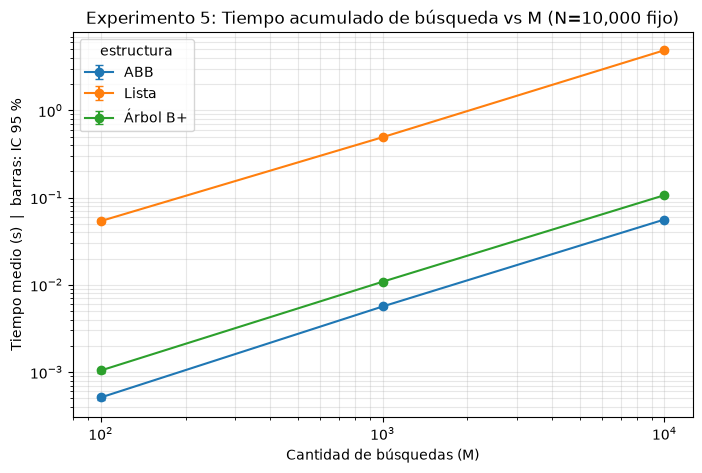

,estructura,M,n,media,desviacion,mediana,iqr,ic_inf,ic_sup,atipicos,n_sin,media_sin,desviacion_sin,mediana_sin,iqr_sin,ic_inf_sin,ic_sup_sin
0,ABB,100,30,5.114700e+05,7.355943e+04,4.953500e+05,24700.0,4.840025e+05,5.389375e+05,2,28,4.966500e+05,1.535022e+04,4.938000e+05,18700.0,4.906978e+05,5.026022e+05
1,ABB,1000,30,5.642643e+06,5.320693e+05,5.713450e+06,830125.0,5.443965e+06,5.841321e+06,0,30,5.642643e+06,5.320693e+05,5.713450e+06,830125.0,5.443965e+06,5.841321e+06
2,ABB,10000,30,5.605723e+07,1.308074e+06,5.624770e+07,1322975.0,5.556879e+07,5.654568e+07,3,27,5.615363e+07,8.619449e+05,5.632060e+07,1086100.0,5.581266e+07,5.649461e+07
3,Lista,100,30,5.378871e+07,8.743661e+06,5.061375e+07,9204250.0,5.052377e+07,5.705365e+07,3,27,5.164277e+07,6.092989e+06,5.046990e+07,7214450.0,4.923246e+07,5.405307e+07
4,Lista,1000,30,4.920558e+08,3.026280e+07,4.848996e+08,22284600.0,4.807555e+08,5.033561e+08,3,27,4.844544e+08,1.898211e+07,4.819893e+08,22887550.0,4.769453e+08,4.919635e+08
5,Lista,10000,30,4.887123e+09,2.373858e+08,4.866272e+09,137442575.0,4.798482e+09,4.975765e+09,4,26,4.875957e+09,9.999463e+07,4.866272e+09,128493400.0,4.835568e+09,4.916346e+09
6,Árbol B+,100,30,1.042247e+06,1.487116e+05,9.754500e+05,84775.0,9.867168e+05,1.097776e+06,4,26,9.917231e+05,4.280399e+04,9.720000e+05,63425.0,9.744342e+05,1.009012e+06
7,Árbol B+,1000,30,1.084687e+07,4.561180e+05,1.068160e+07,784225.0,1.067655e+07,1.101719e+07,0,30,1.084687e+07,4.561180e+05,1.068160e+07,784225.0,1.067655e+07,1.101719e+07
8,Árbol B+,10000,30,1.065390e+08,2.276887e+06,1.059138e+08,2693475.0,1.056888e+08,1.073892e+08,1,29,1.062715e+08,1.773587e+06,1.057897e+08,2371600.0,1.055968e+08,1.069461e+08


In [ ]:
# Escritas con asistencia de IA (Gemini, Google, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3. Estructura basada en los experimentos anteriores.
import pandas as pd

# Importamos las clases de las estructuras de datos
from GestorListaEstudiantes import GestorListaEstudiantes
from ABB import ABB
from ArbolBPlus import ArbolBPlus

# Importamos las funciones para generar datos y medir tiempos
from funciones_auxiliares import (
    generar_estudiantes,
    generar_ids_busqueda,
    medir_busquedas
)



# 1. CONFIGURACIÓN DE PARÁMETROS
N_FIJO = 10_000                             # Base de datos fija de N = 10.000
CANTIDADES_M = [100, 1_000, 10_000] # Cantidades de búsquedas a probar
REPETICIONES = 30                           # 30 ejecuciones oficiales
CALENTAMIENTO = 3                          # 3 ejecuciones previas descartadas
SEMILLA_BASE = 5000                         # Semilla para reproductibilidad
ORDEN_BPLUS = 4                             # Factor de ramificación Árbol B+

mediciones_crudas = []



# 2. CONSTRUCCIÓN DE LA BASE DE DATOS FIJA (N = 10.000)

print("Construyendo estructuras con N = 10000 estudiantes...")

# Generamos N = 10.000 estudiantes aleatorios una sola vez
estudiantes_fijos = generar_estudiantes(N_FIJO, ordenados=False, semilla=9999)

# Inicializamos y cargamos los datos en las 3 estructuras
lista = GestorListaEstudiantes(list(estudiantes_fijos))

abb = ABB()
abb.construir_arbol(estudiantes_fijos)

arbol_bplus = ArbolBPlus(ORDEN_BPLUS)
arbol_bplus.construir_arbol(estudiantes_fijos)

estructuras = {
    "Lista": lista,
    "ABB": abb,
    "Árbol B+": arbol_bplus
}



# 3. BUCLE EXPERIMENTAL

for m in CANTIDADES_M:
    print(f"Procesando M = {m:,} búsquedas...")

    for i in range(REPETICIONES):
        semilla_actual = SEMILLA_BASE + i

        # Generamos las M consultas (80% exitosas, 20% fallidas)
        ids_busqueda = generar_ids_busqueda(
            estudiantes_fijos,
            cantidad_m=m,
            proporcion_existentes=0.8,
            semilla=semilla_actual
        )

        for nombre, estructura in estructuras.items():
            # Pasadas de calentamiento (sin registrar)
            for _ in range(CALENTAMIENTO):
                medir_busquedas(estructura, ids_busqueda)

            # Medición oficial: tiempo acumulado para resolver las M búsquedas
            tiempo_ns = medir_busquedas(estructura, ids_busqueda)

            # Guardar la medición cruda
            mediciones_crudas.append({
                "M": m,
                "N": N_FIJO,
                "repeticion": i + 1,
                "semilla": semilla_actual,
                "estructura": nombre,
                "tiempo_ns": tiempo_ns
            })



# 4. PROCESAMIENTO Y GUARDADO DE RESULTADOS
df_crudas = pd.DataFrame(mediciones_crudas)

# Guardar mediciones crudas en CSV
ruta_crudas = guardar_csv(df_crudas, "e5_mediciones_crudas")

# Calcular tabla de resumen estadístico agrupando por estructura y M
df_resumen = resumir_tabla(df_crudas, columna_curva="estructura", columna_x="M")
ruta_resumen = guardar_csv(df_resumen, "e5_tiempo_busqueda_vs_m")

print(f"\n¡Experimento 5 finalizado con éxito!")
print(f"Mediciones guardadas en: {ruta_crudas}")
print(f"Resumen guardado en: {ruta_resumen}\n")



# 5. CÁLCULO DE PENDIENTES LOG-LOG (Exponente b respecto a M)
print("=== PENDIENTES LOG-LOG (Exponente b con respecto a M) ===")
for nombre, grupo in df_resumen.groupby("estructura"):
    b = pendiente_loglog(grupo["M"], grupo["media"])
    print(f"Estructura: {nombre:<10} | Pendiente (b): {b:.4f}")
print("\n")



# 6. GRAFICAR TIEMPO ACUMULADO VS M
graficar(
    resumen=df_resumen,
    columna_curva="estructura",
    columna_x="M",
    titulo=f"Experimento 5: Tiempo acumulado de búsqueda vs M (N={N_FIJO:,} fijo)",
    etiqueta_x="Cantidad de búsquedas (M)",
    unidad="s",
    escala_log=True
)

display(df_resumen)

### Análisis del experimento 5

Los resultados confirman experimentalmente la hipótesis planteada. Cuando el número de registros guardados se mantiene constante ($N = 10000$), el costo promedio de resolver una búsqueda individual no cambia. Por lo tanto, el tiempo total acumulado escala de forma lineal ($O(M)$) respecto a la cantidad de búsquedas $M$ ejecutadas.

La siguiente tabla resume los tiempos medios acumulados (en milisegundos) y las pendientes obtenidas en la gráfica log-log:

| Estructura | Pendiente (b) | M=100          | M=1000         | M=10000                             |
| -------------- | ----------------- | ------------------ | ------------------- | ---------------------------------------- |
| **ABB**        | $1.020$           | $0.51 \text{ ms}$  | $5.64 \text{ ms}$   | $56.06 \text{ ms}$                       |
| **Árbol B+**   | $1.005$           | $1.04 \text{ ms}$  | $10.85 \text{ ms}$  | $106.54 \text{ ms}$                      |
| **Lista**      | $0.979$           | $53.79 \text{ ms}$ | $492.06 \text{ ms}$ | $4887.12 \text{ ms}$ ($4.89 \text{ s}$) |

Se observa que:
1. Las pendientes calculadas son aproximadamente iguales a $1.0$ en las tres estructuras (ABB: $1.020$, Árbol B+: $1.005$, Lista: $0.979$). Esto permite inferir que multiplicar por $10$ la cantidad de consultas ($M$) incrementa el tiempo total en un factor aproximado de $10$, produciendo tres curvas con la apariencia de rectas paralelas en la gráfica.

2. A pesar de compartir pendientes que apuntan al mismo crecimiento lineal, la eficiencia interna de cada estructura marca una diferencia considerable en el tiempo total. El ABB fue la estructura más rápida, completando $10000$ búsquedas en solo $56.06 \text{ ms}$; el Árbol B+ requiere aproximadamente el doble de tiempo que el ABB ($106.54 \text{ ms}$ para $M = 10000$) debido al procesamiento iterativo adicional que ya se ha mencionado en experimentos previos; por último, la lista muestra el menor desempeño, pues requiere recorrer los nodos uno a uno ($O(N)$) en cada una de las $M$ búsquedas.

### Datos atípicos e intervalos de confianza
1. Los intervalos de confianza son, en general, estrechos en cada una de las configuraciones. No se observan solapamientos entre algoritmos.
2. La cantidad de valores atípicos fue reducida (con un máximo de $4$). La diferencia entre la media global y la media recalculada sin atípicos es baja, lo que permite afirmar que las fluctuaciones del entorno de ejecución no alteran la tendencia general.

## Experimento 6: Tiempo de listado ordenado vs N

> Sección redactada con asistencia de IA (Gemini, Google, y Claude, Anthropic; octubre 2026) y revisada por Daniel Sánchez Escobar.

**Pregunta.** ¿Cómo crece el tiempo necesario para generar el listado completo de estudiantes, ordenado de menor a mayor ID, cuando aumenta el tamaño de los datos ($N$)? ¿Se nota la diferencia entre la Lista, que debe ordenar, y los árboles, que ya guardan los datos en orden?

**Hipótesis (según la teoría).**
- **ABB y Árbol B+:** los datos ya están ordenados dentro de la estructura, así que solo hay que recorrerlos. El ABB lo hace con el recorrido in-orden (izquierda, nodo, derecha) y el B+ recorriendo sus hojas enlazadas. El costo es $O(N)$, es decir, una pendiente log-log cercana a $1$.
- **Lista:** guarda los estudiantes sin orden, así que antes de generar el listado debe ordenarlos con `sorted()`, que cuesta $O(N \log N)$. Se espera una pendiente algo por encima de $1$.
- No se plantea una hipótesis sobre cuál estructura es la más rápida en tiempo absoluto: en las tres, el tiempo incluye armar el texto de cada estudiante (trabajo lineal y común a todas), y la diferencia dependerá de los detalles de cada implementación.

### Diseño

| Elemento | Valor |
|---|---|
| Tamaños de datos ($N$) | $100, 1000, 10000$ y $100000$ |
| Tipo de datos | IDs únicos y aleatorios (sin orden) |
| Estructuras | Lista, ABB y Árbol B+ (orden $4$) |
| Operación medida | `listar()`: recorrer todos los estudiantes y armar el texto del listado, ordenado por ID |
| Repeticiones | $30$ por configuración |
| Calentamiento | $3$ listados descartados antes de cada medición |
| Cómo se mide | `time.perf_counter_ns()` con el recolector de basura desactivado |
| Semilla | $6000 + N$: una por tamaño de datos (ver nota) |

Para cada $N$ se genera un conjunto de estudiantes y se construyen las tres estructuras con los mismos datos. La construcción queda fuera del cronómetro: solo se mide el listado. Las tres estructuras se construyen una sola vez por $N$ y el listado se repite $30$ veces sobre cada una. Los tiempos crudos se guardan en `e6_mediciones_crudas.csv` y el resumen estadístico en `e6_tiempo_listado_vs_n.csv`.

**Nota sobre la semilla.** En este experimento hay un solo conjunto de datos por tamaño (semilla $6000 + N$), a diferencia de los experimentos 1 y 2, donde cada repetición usaba datos nuevos. Por eso los intervalos de confianza reflejan solo el ruido de la medición y no la variación entre conjuntos de datos distintos.

Procesando N = 100 estudiantes...
Procesando N = 1,000 estudiantes...
Procesando N = 10,000 estudiantes...
Procesando N = 100,000 estudiantes...

¡Experimento 6 finalizado con éxito!
Mediciones guardadas en: resultados/e6_mediciones_crudas.csv
Resumen guardado en: resultados/e6_tiempo_listado_vs_n.csv

=== PENDIENTES LOG-LOG (Exponente b con respecto a N) ===
Estructura: ABB        | Pendiente (b): 1.0345
Estructura: Lista      | Pendiente (b): 1.0378
Estructura: Árbol B+   | Pendiente (b): 1.0502




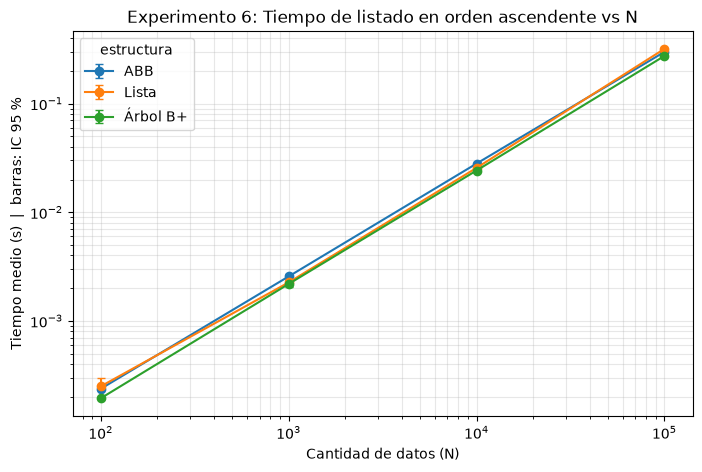

,estructura,N,n,media,desviacion,mediana,iqr,ic_inf,ic_sup,atipicos,n_sin,media_sin,desviacion_sin,mediana_sin,iqr_sin,ic_inf_sin,ic_sup_sin
0,ABB,100,30,2.368567e+05,1.614370e+04,233600.0,3800.0,2.308285e+05,2.428848e+05,1,29,2.339655e+05,3.195116e+03,233500.0,2700.0,2.327502e+05,2.351809e+05
1,ABB,1000,30,2.563817e+06,3.355144e+05,2490500.0,252475.0,2.438534e+06,2.689100e+06,1,29,2.510459e+06,1.677123e+05,2469600.0,230300.0,2.446664e+06,2.574253e+06
2,ABB,10000,30,2.805974e+07,1.438245e+06,27598750.0,767300.0,2.752269e+07,2.859679e+07,4,26,2.761198e+07,4.385596e+05,27555150.0,660975.0,2.743484e+07,2.778911e+07
3,ABB,100000,30,2.995493e+08,9.216855e+06,297290500.0,2985250.0,2.961076e+08,3.029909e+08,3,27,2.970254e+08,2.060651e+06,297144100.0,2979650.0,2.962102e+08,2.978405e+08
4,Lista,100,30,2.493433e+05,1.351459e+05,205000.0,5150.0,1.988790e+05,2.998076e+05,4,26,2.053000e+05,3.341018e+03,204800.0,4700.0,2.039505e+05,2.066495e+05
5,Lista,1000,30,2.258230e+06,3.069727e+05,2170750.0,215600.0,2.143605e+06,2.372855e+06,2,28,2.187896e+06,1.158886e+05,2145850.0,173150.0,2.142960e+06,2.232833e+06
6,Lista,10000,30,2.561532e+07,2.860455e+06,24693150.0,769650.0,2.454721e+07,2.668343e+07,6,24,2.448921e+07,5.199342e+05,24512850.0,545250.0,2.426966e+07,2.470876e+07
7,Lista,100000,30,3.194838e+08,5.783280e+06,317917950.0,4311025.0,3.173243e+08,3.216433e+08,3,27,3.178958e+08,2.856588e+06,317320700.0,2934800.0,3.167658e+08,3.190258e+08
8,Árbol B+,100,30,1.936200e+05,3.222914e+03,193250.0,1950.0,1.924165e+05,1.948235e+05,2,28,1.929500e+05,1.635146e+03,193100.0,1925.0,1.923160e+05,1.935840e+05
9,Árbol B+,1000,30,2.185783e+06,3.582764e+05,2099400.0,297925.0,2.052001e+06,2.319566e+06,3,27,2.085170e+06,1.637151e+05,2037700.0,244950.0,2.020407e+06,2.149934e+06


In [4]:
# Escritas con asistencia de IA (Gemini, Google, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3. Estructura basada en los experimentos anteriores.
import pandas as pd

# Importamos las clases de las estructuras de datos
from GestorListaEstudiantes import GestorListaEstudiantes
from ABB import ABB
from ArbolBPlus import ArbolBPlus

# Importamos las funciones para generar datos y medir tiempos
from funciones_auxiliares import (
    generar_estudiantes,
    medir_listado
)

# 1. CONFIGURACIÓN DE PARÁMETROS
TAMANOS_N = [100, 1_000, 10_000, 100_000]       # Tamaños N a evaluar (potencias de 10)
REPETICIONES = 30                               # 30 ejecuciones oficiales
CALENTAMIENTO = 3                              # 3 ejecuciones previas descartadas
SEMILLA_BASE = 6000                             # Semilla para reproductibilidad
ORDEN_BPLUS = 4                                 # Factor de ramificación Árbol B+

mediciones_crudas = []


# 2. BUCLE EXPERIMENTAL (TIEMPO DE LISTADO VS N)
for n in TAMANOS_N:
    print(f"Procesando N = {n:,} estudiantes...")

    # Semilla fija asociada a este conjunto de datos N
    semilla_dataset = SEMILLA_BASE + n

    # Generamos los datos desordenados para el tamaño N actual
    estudiantes = generar_estudiantes(n, ordenados=False, semilla=semilla_dataset)

    # Inicializamos y cargamos los datos en las 3 estructuras
    lista = GestorListaEstudiantes(list(estudiantes))

    abb = ABB()
    abb.construir_arbol(estudiantes)

    arbol_bplus = ArbolBPlus(ORDEN_BPLUS)
    arbol_bplus.construir_arbol(estudiantes)

    estructuras = {
        "Lista": lista,
        "ABB": abb,
        "Árbol B+": arbol_bplus
    }

    # Repetimos la medición del listado ordenado sobre las estructuras construidas
    for i in range(REPETICIONES):
        for nombre, estructura in estructuras.items():
            # Pasadas de calentamiento (sin registrar)
            for _ in range(CALENTAMIENTO):
                medir_listado(estructura)

            # Medición oficial: tiempo para generar el listado en orden ascendente
            tiempo_ns = medir_listado(estructura)

            # Guardar la medición cruda
            mediciones_crudas.append({
                "N": n,
                "repeticion": i + 1,
                "semilla": semilla_dataset,
                "estructura": nombre,
                "tiempo_ns": tiempo_ns
            })


# 3. PROCESAMIENTO Y GUARDADO DE RESULTADOS
df_crudas = pd.DataFrame(mediciones_crudas)

# Guardar mediciones crudas en CSV
ruta_crudas = guardar_csv(df_crudas, "e6_mediciones_crudas")

# Calcular tabla de resumen estadístico agrupando por estructura y N
df_resumen = resumir_tabla(df_crudas, columna_curva="estructura", columna_x="N")
ruta_resumen = guardar_csv(df_resumen, "e6_tiempo_listado_vs_n")

print(f"\n¡Experimento 6 finalizado con éxito!")
print(f"Mediciones guardadas en: {ruta_crudas}")
print(f"Resumen guardado en: {ruta_resumen}\n")


# 4. CÁLCULO DE PENDIENTES LOG-LOG (Exponente b respecto a N)
print("=== PENDIENTES LOG-LOG (Exponente b con respecto a N) ===")
for nombre, grupo in df_resumen.groupby("estructura"):
    b = pendiente_loglog(grupo["N"], grupo["media"])
    print(f"Estructura: {nombre:<10} | Pendiente (b): {b:.4f}")
print("\n")


# 5. GRAFICAR TIEMPO DE LISTADO VS N
graficar(
    resumen=df_resumen,
    columna_curva="estructura",
    columna_x="N",
    titulo="Experimento 6: Tiempo de listado en orden ascendente vs N",
    etiqueta_x="Cantidad de datos (N)",
    unidad="s",
    escala_log=True
)

display(df_resumen)

## Análisis del experimento 6

Para empezar, es importante mencionar que la operación "listar" incluye recorrer todos los estudiantes y construir el texto correspondiente a cada uno, por lo que esta parte del trabajo es común a las tres estructuras implementadas en este laboratorio. Por ello, se espera que sus tiempos presenten comportamientos similares. La principal diferencia es que la Lista debe ordenar explícitamente los registros antes de generar el reporte (utiliza el método sorted de Python), mientras que el ABB y el Árbol B+ aprovechan la organización que ya poseen por su propia estructura para obtener los elementos en orden ascendente.

La siguiente tabla muestra los tiempos medios de listado con todos los datos (en milisegundos) y las pendientes obtenidas log-log.

| Estructura |  N=100 | N=1.000 | N=10.000 | N=100.000 | Pendiente (b) |
| -------------- | ---------: | ----------: | -----------: | ------------: | ----------------: |
| **ABB**        | $0.237$ ms |  $2.564$ ms |  $28.060$ ms |  $299.549$ ms |          $1.0345$ |
| **Lista**      | $0.249$ ms |  $2.258$ ms |  $25.615$ ms |  $319.484$ ms |          $1.0378$ |
| **Árbol B+**   | $0.194$ ms |  $2.186$ ms |  $24.222$ ms |  $275.024$ ms |          $1.0502$ |

Se observa que:

1. Las tres estructuras presentan un crecimiento aproximadamente lineal, es decir, todas las pendientes son cercanas a $1.0$ (ABB: $1.0345$, Lista: $1.0378$ y Árbol B+: $1.0502$). Esto coincide con que las tres deben procesar los $N$ estudiantes y construir el reporte completo. Este comportamiento asintótico es de esperarse para los árboles (según la teoría). Sin embargo, es notable que los resultados no permiten identificar experimentalmente un comportamiento $O(N\log N)$ en la Lista a partir de la pendiente Log-Log estimada.

2. El Árbol B+ presenta los menores tiempos medios en todos los tamaños evaluados. Para $N=100000$, por ejemplo, requiere aproximadamente $275.024$ ms, frente a $299.549$ ms del ABB y $319.484$ ms de la Lista. Una posible explicación es que el B+ puede recorrer secuencialmente las hojas enlazadas una vez alcanzada la primera hoja, mientras que el ABB debe realizar un recorrido recursivo in-orden utilizando una pila explícita.

4. El orden entre la Lista y el ABB cambia con $N$. Para $N=1000$ y $N=10000$, la Lista presenta menores tiempos medios que el ABB. Para $N=100000$, en cambio, la Lista pasa a ser la más lenta de las tres estructuras, con $319.484$ ms frente a $299.549$ ms del ABB y $275.024$ ms del B+. Para $N=100$, la Lista presenta la mayor media ($0.249$ ms), pero esta medición está afectada por cuatro valores atípicos. Al excluir los atípicos, su media disminuye a $0.205$ ms, por debajo de los $0.234$ ms del ABB.

### Efecto del ordenamiento en la Lista

Como ya se mencionó, el listado de la Lista combina dos operaciones principales. Primero se ordenan los registros mediante el método nativo sorted y posteriormente se recorren los estudiantes para construir el texto del reporte. En el caso del ABB y el Árbol B+, no se necesita realizar ese ordenamiento explícito porque sus estructuras permiten obtener los registros en orden. Para el caso de la lista puede decirse que el costo asociado a la generación del reporte de estudiantes todavía tiene un peso considerable en el tiempo total de la Lista, por lo que el peso del ordenamiento no se refleja claramente en la pendiente estimada (para los tamaños $N$ evaluados). Además, no puede ignorarse que la función sorted es una operación altamente optimizada de CPython, por lo que su costo puede ser relativamente pequeño frente al trabajo realizado posteriormente en Python puro para construir el reporte.

Sin embargo, el comportamiento asintótico y la regla de acotamiento permite inferir que a medida que $N$ siga creciendo, el costo del ordenamiento predomine sobre el costo lineal. Este hecho empieza a hacerse ligeramente más visible para $N=100000$, la Lista requiere $319.484$ ms, más que el Árbol B+ ($275.024$ ms) y el ABB ($299.549$ ms). Esto es compatible con que el costo adicional del ordenamiento tenga una mayor influencia a medida que aumenta el número de estudiantes. Sin embargo, una limitación de este experimento es que no separa el tiempo de ordenamiento del tiempo de generación del reporte, por lo que no permite determinar cuánto del incremento corresponde específicamente a sorted ni evalúa valores mayores para $N$ (principalmente por restricciones de tiempo del experimento).

### Datos atípicos e intervalos de confianza

1. Se presentaron pocos valores atípicos por configuración, entre $1$ y $6$. Al excluirlos, las medias cambian poco en la mayoría de las configuraciones. La principal excepción corresponde a la Lista con $N=100$, cuya media disminuye de $0.249$ ms a $0.205$ ms debido a la presencia de cuatro mediciones atípicas.

2. Al recalcular las pendientes sin los valores atípicos, se obtienen aproximadamente $1.035$ para el ABB, $1.062$ para la Lista y $1.052$ para el Árbol B+ (Ver código de la siguiente celda). En este caso, la Lista si presenta la pendiente más alta, como sería esperable por la presencia del ordenamiento. Sin embargo, la diferencia sigue siendo pequeña y no permite establecer por sí sola un comportamiento $O(N\log N)$.

In [6]:
print("=== PENDIENTES LOG-LOG (Exponente b con respecto a N) ===")
for nombre, grupo in df_resumen.groupby("estructura"):
    b = pendiente_loglog(grupo["N"], grupo["media_sin"])
    print(f"Estructura: {nombre:<10} | Pendiente (b): {b:.4f}")
print("\n")


=== PENDIENTES LOG-LOG (Exponente b con respecto a N) ===
Estructura: ABB        | Pendiente (b): 1.0352
Estructura: Lista      | Pendiente (b): 1.0619
Estructura: Árbol B+   | Pendiente (b): 1.0519




3. Con todos los datos, los intervalos de confianza presentan solapamiento entre la Lista y el ABB para $N=100$. También existe solapamiento entre la Lista y el Árbol B+ para $N=1000$. Para las demás comparaciones, los intervalos permanecen separados.

4. Después de excluir los valores atípicos, el ABB presenta intervalos separados de los de las otras dos estructuras para todos los tamaños. Entre la Lista y el Árbol B+ permanece un pequeño solapamiento para $N=1000$ y $N=10000$. Por tanto, las diferencias entre ambas estructuras en estos tamaños son pequeñas en relación con la variabilidad de las mediciones.

## Experimento 7: Búsqueda por rango vs N (con K = 50)

> Sección redactada con asistencia de IA (Gemini, Google, y Claude, Anthropic; octubre 2026) y revisada por Daniel Sánchez Escobar.

**Pregunta.** ¿Cómo escala el tiempo acumulado de ejecución al realizar consultas por rango de tamaño fijo ($K = 50$) a medida que aumenta la cantidad total de datos guardados ($N$)? ¿Las estructuras jerárquicas (ABB y Árbol B+) mantienen una complejidad sublineal/logarítmica respecto a $N$, mientras que la Lista se degrada de forma estrictamente lineal $O(N)$ debido a la necesidad de inspeccionar todos los registros?

**Hipótesis.** Al fijar el número de resultados retornados por consulta en $K = 50$, el tiempo de ejecución dependerá principalmente de la eficiencia de cada estructura para localizar el inicio del rango y recorrer únicamente las claves coincidentes:

1. Árbol B+ ($O(\log N + K)$): Desciende desde la raíz hasta la hoja del límite inferior en $O(\log N)$ (mejor caso) y recorre secuencialmente las hojas adyacentes mediante punteros para recuperar los $K$ elementos. Al ser $K$ constante, la complejidad efectiva por consulta es $O(\log N)$. La pendiente log-log ($b$) será cercana a $0.0$ (o ligeramente superior por el costo base de iteración).   
2. ABB ($O(\log N + K)$): Localiza el límite inferior en $O(\log N)$ en promedio y realiza un recorrido in-orden acotado que descarta subárboles fuera de rango. Su tiempo por consulta escala como $O(\log N)$, proyectando también una pendiente log-log cercana a $0.0$.   
3. Lista ($O(N)$): Al carecer de orden jerárquico, debe iterar linealmente los $N$ elementos de la lista para filtrar los que caen dentro del intervalo $[lb, ub]$ ($O(N)$). Como $N$ mayor a $K$, el costo dominante es $O(N)$, por lo que la pendiente log-log ($b$) de la Lista tenderá a $1.0$.

### Diseño:
1. Para cada tamaño $N \in \{100, 1000, 10000, 100000\}$, se genera un conjunto desordenado de $N$ estudiantes utilizando una semilla fija asociada (SEMILLA_BASE + N) para asegurar reproductibilidad.   
2. Se construyen y pueblan las tres estructuras a evaluar: Lista, ABB y Árbol B+ (con $n = 4$).   En cada repetición $i$, se utiliza la función generar_rangos_por_tamano() con la semilla SEMILLA_BASE + N + i para obtener $M = 100$ rangos $[lb, ub]$ que contienen exactamente $K = 50$ estudiantes cada uno.   
3. Se mide el tiempo total acumulado en nanosegundos para procesar las $M$ consultas por rango en cada estructura, ejecutando $3$ pasadas previas de calentamiento y $30$ repeticiones oficiales por cada valor de $N$.

### Variables del experimento:

| Variable              | Configuración           | Significado                                                             |
|---------------------------|-----------------------------|-----------------------------------------------------------------------------|
| **Tamaño de datos ($N$)** | $100, 1000, 10000, 100000$ | Cantidad total de estudiantes almacenados en cada estructura.               |
| **Tamaño del rango ($K$)** | $50$ (fijo)                | Cantidad exacta de estudiantes contenidos en cada rango de consulta.        |
| **Consultas ($M$)**       | $100$                       | Cantidad de búsquedas por rango ejecutadas en cada prueba.                  |
| **Estructuras**           | Lista, ABB, Árbol B+       | Algoritmos y estructuras de datos a comparar.                               |
| **Orden B+ ($n$)**        | $4$                         | Factor de ramificación del Árbol B+.                                        |
| **Repeticiones**          | $30$ ejecuciones            | Corridas independientes por configuración con $3$ pasadas de calentamiento. |

Procesando N = 100 estudiantes...
Procesando N = 1,000 estudiantes...
Procesando N = 10,000 estudiantes...
Procesando N = 100,000 estudiantes...

¡Experimento 7 finalizado con éxito!
Mediciones guardadas en: resultados/e7_mediciones_crudas.csv
Resumen guardado en: resultados/e7_tiempo_rango_vs_n.csv

=== PENDIENTES LOG-LOG (Exponente b con respecto a N) ===
Estructura: ABB        | Pendiente (b): 0.0346
Estructura: Lista      | Pendiente (b): 0.7339
Estructura: Árbol B+   | Pendiente (b): 0.0422




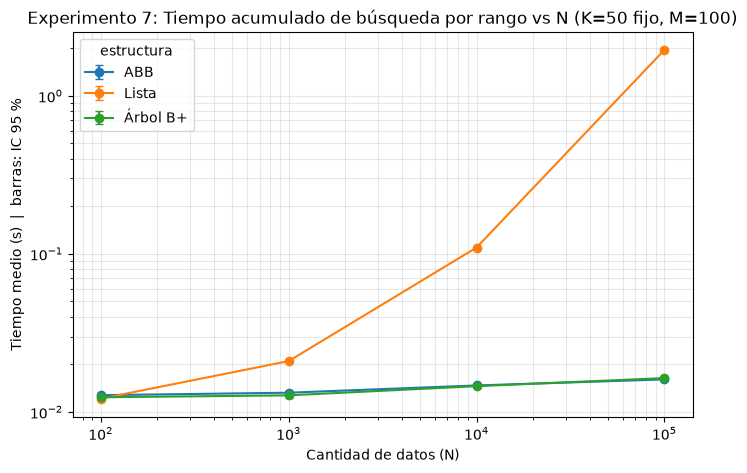

,estructura,N,n,media,desviacion,mediana,iqr,ic_inf,ic_sup,atipicos,n_sin,media_sin,desviacion_sin,mediana_sin,iqr_sin,ic_inf_sin,ic_sup_sin
0,ABB,100,30,1.276797e+07,5.198216e+05,1.250355e+07,423950.0,1.257387e+07,1.296208e+07,7,23,1.249897e+07,1.514371e+05,1.248770e+07,127000.0,1.243349e+07,1.256446e+07
1,ABB,1000,30,1.323791e+07,1.136275e+06,1.274410e+07,712675.0,1.281361e+07,1.366220e+07,4,26,1.285643e+07,4.472629e+05,1.271435e+07,613150.0,1.267578e+07,1.303708e+07
2,ABB,10000,30,1.471206e+07,6.411612e+05,1.458265e+07,605350.0,1.447265e+07,1.495147e+07,2,28,1.458755e+07,4.420592e+05,1.449545e+07,566275.0,1.441614e+07,1.475897e+07
3,ABB,100000,30,1.606989e+07,1.995755e+05,1.604925e+07,187100.0,1.599536e+07,1.614441e+07,2,28,1.603351e+07,1.448917e+05,1.604485e+07,172600.0,1.597733e+07,1.608970e+07
4,Lista,100,30,1.213810e+07,4.210879e+05,1.203840e+07,172700.0,1.198087e+07,1.229534e+07,4,26,1.200720e+07,1.160480e+05,1.199885e+07,143775.0,1.196033e+07,1.205407e+07
5,Lista,1000,30,2.097888e+07,9.495079e+05,2.079910e+07,555850.0,2.062433e+07,2.133344e+07,2,28,2.078062e+07,3.414352e+05,2.078290e+07,515450.0,2.064822e+07,2.091301e+07
6,Lista,10000,30,1.097226e+08,4.329985e+06,1.089792e+08,2954400.0,1.081057e+08,1.113394e+08,2,28,1.087226e+08,2.089884e+06,1.087658e+08,2637750.0,1.079122e+08,1.095330e+08
7,Lista,100000,30,1.954078e+09,2.267115e+07,1.953339e+09,16862675.0,1.945612e+09,1.962543e+09,4,26,1.952811e+09,1.429896e+07,1.953339e+09,12213275.0,1.947036e+09,1.958586e+09
8,Árbol B+,100,30,1.238552e+07,1.001504e+06,1.196415e+07,306625.0,1.201155e+07,1.275949e+07,6,24,1.192202e+07,1.683541e+05,1.191450e+07,237225.0,1.185093e+07,1.199311e+07
9,Árbol B+,1000,30,1.273684e+07,1.102206e+06,1.240990e+07,571275.0,1.232527e+07,1.314841e+07,3,27,1.244230e+07,3.895835e+05,1.237720e+07,539700.0,1.228819e+07,1.259642e+07


In [9]:
# Escritas con asistencia de IA (Gemini, Google, octubre 2026), según lo
# permitido por el enunciado del Laboratorio 3. Estructura basada en los experimentos anteriores.
import pandas as pd

# Importamos las clases de las estructuras de datos
from GestorListaEstudiantes import GestorListaEstudiantes
from ABB import ABB
from ArbolBPlus import ArbolBPlus

# Importamos las funciones para generar datos y medir tiempos
from funciones_auxiliares import (
    generar_estudiantes,
    generar_rangos_por_tamano,
    medir_busquedas_rango
)

# 1. CONFIGURACIÓN DE PARÁMETROS
TAMANOS_N = [100, 1_000, 10_000, 100_000]       # Tamaños N a evaluar
CANTIDAD_M = 100                                # M = 100 consultas por rango por repetición
K_RANGO = 50                                    # K = 50 elementos por rango (FIJO)
REPETICIONES = 30                               # 30 ejecuciones oficiales
CALENTAMIENTO = 3                              # 3 ejecuciones previas descartadas
SEMILLA_BASE = 7000                             # Semilla base para reproductibilidad
ORDEN_BPLUS = 4                                 # Factor de ramificación Árbol B+

mediciones_crudas = []


# 2. BUCLE EXPERIMENTAL (BÚSQUEDA POR RANGO VS N)

for n in TAMANOS_N:
    print(f"Procesando N = {n:,} estudiantes...")

    # Semilla fija asociada al dataset para el tamaño N actual
    semilla_dataset = SEMILLA_BASE + n

    # Generamos los datos desordenados para el tamaño N actual
    estudiantes = generar_estudiantes(n, ordenados=False, semilla=semilla_dataset)

    # Inicializamos y cargamos los datos en las 3 estructuras
    lista = GestorListaEstudiantes(list(estudiantes))

    abb = ABB()
    abb.construir_arbol(estudiantes)

    arbol_bplus = ArbolBPlus(ORDEN_BPLUS)
    arbol_bplus.construir_arbol(estudiantes)

    estructuras = {
        "Lista": lista,
        "ABB": abb,
        "Árbol B+": arbol_bplus
    }

    for i in range(REPETICIONES):
        # Semilla para generar los M rangos aleatorios de K=50 en esta repetición
        semilla_rangos = SEMILLA_BASE + n + i

        # Generamos M rangos que contienen exactamente K = 50 estudiantes
        rangos_busqueda = generar_rangos_por_tamano(
            estudiantes,
            cantidad_m=CANTIDAD_M,
            k=K_RANGO,
            semilla=semilla_rangos
        )

        for nombre, estructura in estructuras.items():
            # Pasadas de calentamiento (sin registrar)
            for _ in range(CALENTAMIENTO):
                medir_busquedas_rango(estructura, rangos_busqueda)

            # Medición oficial: tiempo acumulado para resolver las M búsquedas por rango
            tiempo_ns = medir_busquedas_rango(estructura, rangos_busqueda)

            # Guardar la medición cruda
            mediciones_crudas.append({
                "N": n,
                "repeticion": i + 1,
                "semilla": semilla_rangos,
                "estructura": nombre,
                "tiempo_ns": tiempo_ns
            })


# 3. PROCESAMIENTO Y GUARDADO DE RESULTADOS
df_crudas = pd.DataFrame(mediciones_crudas)

# Guardar mediciones crudas en CSV
ruta_crudas = guardar_csv(df_crudas, "e7_mediciones_crudas")

# Calcular tabla de resumen estadístico agrupando por estructura y N
df_resumen = resumir_tabla(df_crudas, columna_curva="estructura", columna_x="N")
ruta_resumen = guardar_csv(df_resumen, "e7_tiempo_rango_vs_n")

print(f"\n¡Experimento 7 finalizado con éxito!")
print(f"Mediciones guardadas en: {ruta_crudas}")
print(f"Resumen guardado en: {ruta_resumen}\n")


# 4. CÁLCULO DE PENDIENTES LOG-LOG (Exponente b respecto a N)
print("=== PENDIENTES LOG-LOG (Exponente b con respecto a N) ===")
for nombre, grupo in df_resumen.groupby("estructura"):
    b = pendiente_loglog(grupo["N"], grupo["media"])
    print(f"Estructura: {nombre:<10} | Pendiente (b): {b:.4f}")
print("\n")


# 5. GRAFICAR TIEMPO ACUMULADO VS N (EN SEGUNDOS)
graficar(
    resumen=df_resumen,
    columna_curva="estructura",
    columna_x="N",
    titulo=f"Experimento 7: Tiempo acumulado de búsqueda por rango vs N (K={K_RANGO} fijo, M={CANTIDAD_M})",
    etiqueta_x="Cantidad de datos (N)",
    unidad="s",
    escala_log=True
)

display(df_resumen)

## Análisis del experimento 7

Los resultados experimentales confirman que mantener el tamaño del rango de salida fijo ($K = 50$) aísla el costo de búsqueda inicial de cada estructura. Las estructuras jerárquicas (ABB y Árbol B+) exhiben un tiempo de ejecución con crecimiento lento frente al crecimiento de $N$, mientras que la Lista sufre una degradación al tener que inspeccionar la totalidad de los registros.

La siguiente tabla resume los tiempos medios acumulados para $M=100$ consultas (convertidos a milisegundos) y las pendientes obtenidas en la regresión log-log:

| Estructura | Pendiente (b) | N=100          | N=1000        | N=10000        | N=100000        |
|----------------|-------------------|--------------------|--------------------|---------------------|----------------------|
| **ABB**        | $0.0346$          | $12.77 \text{ ms}$ | $13.24 \text{ ms}$ | $14.71 \text{ ms}$  | $16.07 \text{ ms}$   |
| **Árbol B+**   | $0.0422$          | $12.38 \text{ ms}$ | $12.74 \text{ ms}$ | $14.56 \text{ ms}$  | $16.37 \text{ ms}$   |
| **Lista**      | $0.7339$          | $12.14 \text{ ms}$ | $20.98 \text{ ms}$ | $109.72 \text{ ms}$ | $1954.08 \text{ ms} (1.95 \text{s})$ |

Principalmente, se observa que:
1. Tanto el ABB ($b = 0.0346$) como el Árbol B+ ($b = 0.0422$) muestran pendientes muy cercanas a cero, lo que se visualiza como líneas casi horizontales en la gráfica. Al pasar de $100$ a $100000$ estudiantes, el tiempo acumulado de las $100$ consultas apenas se incrementa en unos $3$ a $4 \text{ ms}$. Aquí se puede confirmar el comportamiento sublineal de ambas estructuras.
2. La Lista presenta una pendiente de $0.7339$, evidenciando un crecimiento que tiende a la linealidad conforme $N$ se hace lo suficientemente grande. Para $N = 100000$, la Lista requirió casi $2$ segundos ($1954.08 \text{ ms}$) en completar el mismo lote de consultas que los árboles resolvieron en $16 \text{ ms}$ aproximadamente. Esto se debe a que su algoritmo filtra todos los $N$ elementos de la estructura uno por uno antes de ordenar los coincidentes.
3. Para $N = 100$, las tres estructuras obtienen tiempos casi idénticos (alrededor de $12 \text{ ms}$). Sin embargo, la brecha de rendimiento se vuelve evidente a partir de $N = 1000$.

### Datos atípicos e intervalos de confianza

1.  Los intervalos de confianza para las tres estructuras son notablemente estrechos en todos los tamaños de $N$.
2.  Para $N = 100$, tanto los intervalos de las tres estructuras como la gráfica indican un solapamiento casi completo. Para este valor, los tres algoritmos se comportan prácticamente igual.
3.  La mayor cantidad de valores atípicos se presentó en las pruebas más rápidas, específicamente para el ABB (7 atípicos) y el Árbol B+ (6 atípicos) en $N = 100$. Sin embargo, al comparar la media  con y sin atípicos (media_sin), las diferencias son reducidas y no apuntan a una intepretación diferente de la tendencia que marcan los datos.

# 3. Uso de la IA y código de honor

En la elaboración de este laboratorio se utilizaron IA's generativas (GitHub Copilot, Claude, Gemini) como apoyo para la comprensión del problema, la revisión de la lógica, la redacción del documento y generación de algunos script de código. Su función fue auxiliar en la organización de ideas, clarificar conceptos relacionados con listas, ABB y árboles B+, y mejorar la claridad de la explicación de los resultados experimentales.

La IA no reemplazó el trabajo de análisis, implementación ni validación. El desarrollo del laboratorio, la interpretación de los experimentos y la formulación de las conclusiones fueron realizados con criterio propio y posteriormente revisados para asegurar que el contenido final fuera consistente. En ese sentido, la IA se usó como herramienta de apoyo académico y de redacción.

